# iToF / Structured-Light Fusion Pipeline

Calibration and depth fusion for a combined indirect Time-of-Flight (iToF) and Structured Light (SL).  
Based on:
- **Microsoft-Paper** – Godbaz et al. 2025 (Microsoft): dot calibration, consistency error, active brightness trail
- **Agresti** – Agresti & Zanuttigh, ECCV 2018: maximum likelihood depth fusion

In [87]:
from dot_calibration import DotCalibration

import os
import numpy as np
from pathlib import Path
import scipy.signal
from scipy.spatial import cKDTree
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

dotCal = DotCalibration()

# ── Data paths ──────────────────────────────────────────────────────────
base     = Path.cwd().parent / "Simulation_Pictures" / "PBRT" / "SL_ToF_On"
sl_cal   = base / "SL_OnSemi"           # calibration SL images (.exr)
tof_cal  = base / "ToF_OnSemi"          # calibration ToF point clouds (.pcd)
test_dir = base / "Test_Scenes" # test scene

# ── Camera intrinsics ───────────────────────────────────────────────────
Schmersal = False # True = Schmersal, False = OnSemi


if Schmersal:
    K     = np.array([[503.1,    0.0, 320.0],
                  [  0.0, -503.1, 240.0],
                  [  0.0,    0.0,   1.0]])     #503.1 instead of -362.6 when using 51° FOV (vertical)
else:
    K     = np.array([[1006.2,    0.0, 640.0],
                  [  0.0, -1006.2, 480.0],
                  [  0.0,    0.0,   1.0]])     
    
K_inv = np.linalg.inv(K)
fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

print("Setup complete.")

# ── Figure collection for calibration save ──────────────────────────────
calibration_figures = []   # list of (name, fig) tuples


Setup complete.


## Calibration Steps 1–2: Dot Detection & Subpixel Localisation

LoG blob detection on each calibration SL image, followed by subpixel refinement.
Dots are assigned stable IDs 0–99 (top-left → bottom-right).

Calibration distances: [0.4, 0.44444, 0.5, 0.57143, 0.66666, 0.8, 1.0, 1.33333, 2.0, 4.0]
  Processing 0.4 m …


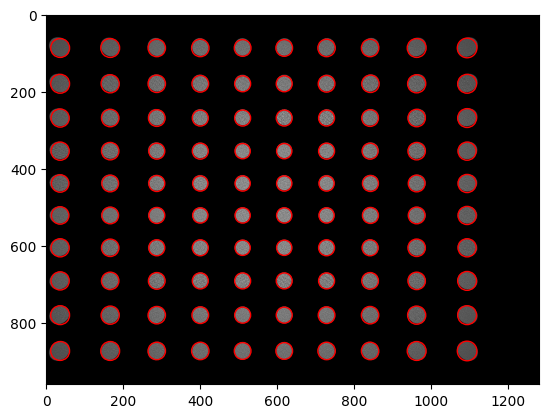

  Processing 0.44444 m …


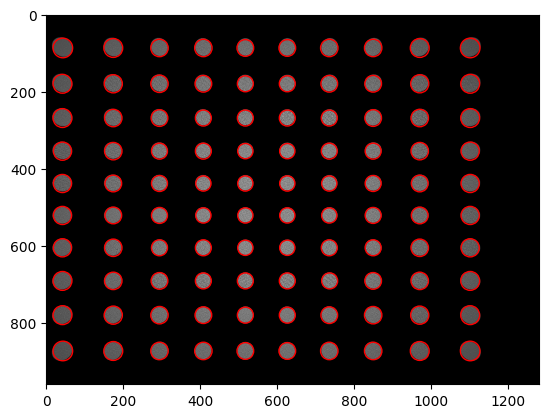

  Processing 0.5 m …


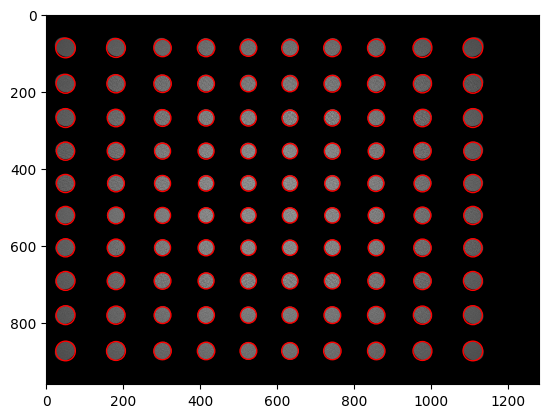

  Processing 0.57143 m …


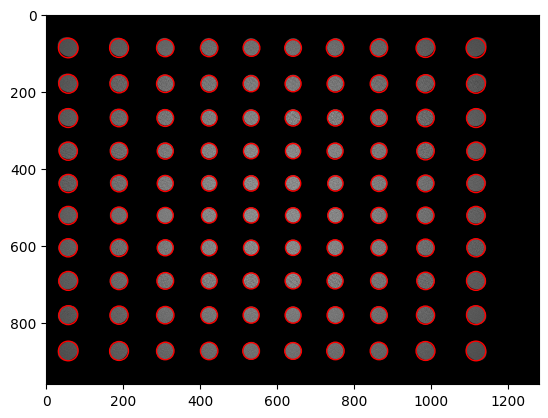

  Processing 0.66666 m …


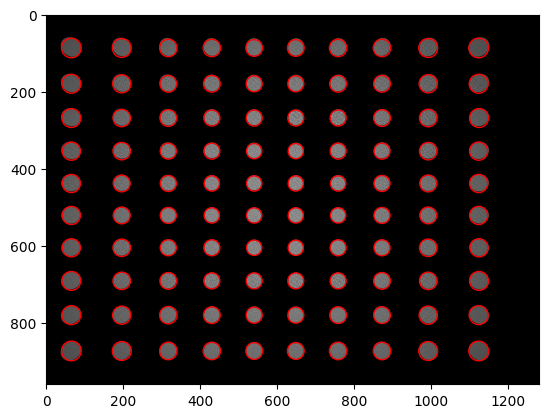

  Processing 0.8 m …


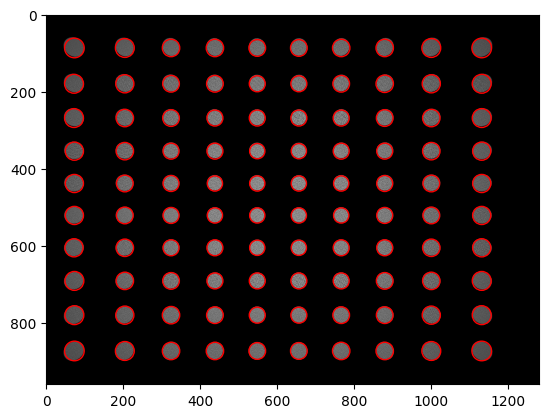

  Processing 1.0 m …


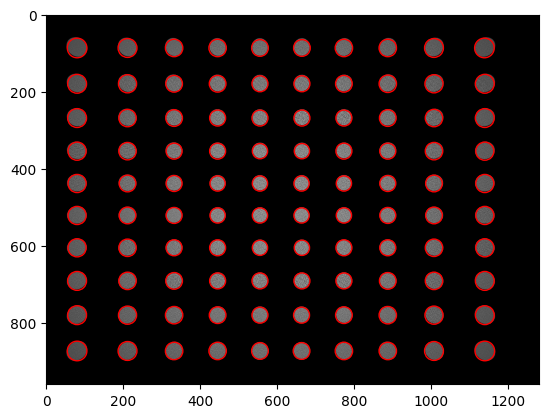

  Processing 1.33333 m …


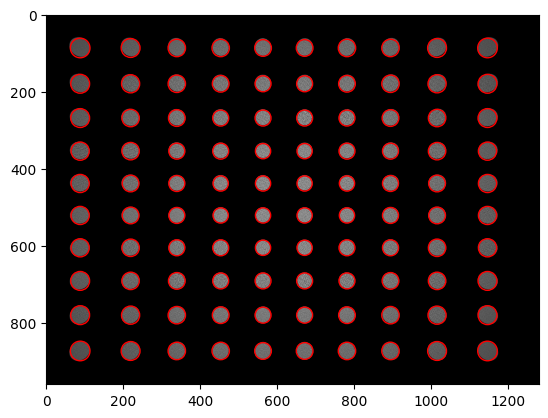

  Processing 2.0 m …


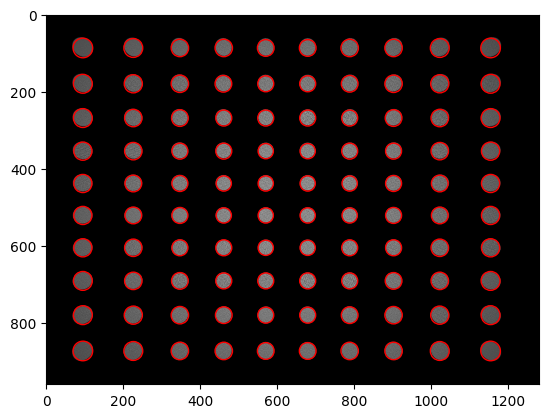

  Processing 4.0 m …


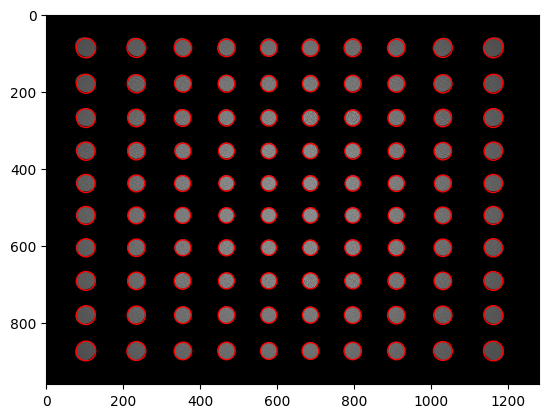


Dots per distance: [100, 100, 100, 100, 100, 100, 100, 100, 100, 100]


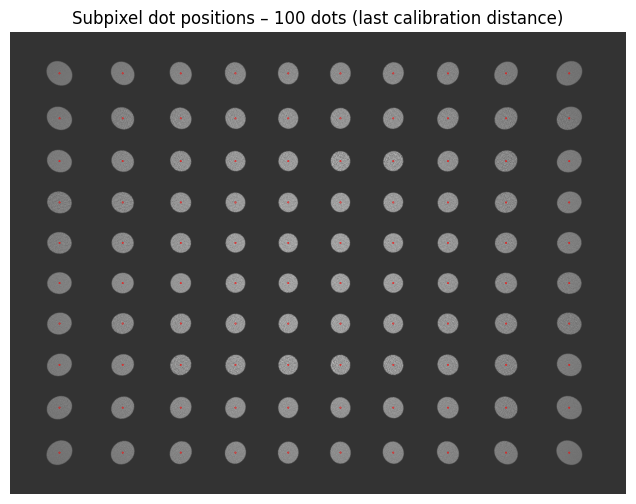

In [88]:
# Collect calibration PCD paths sorted by distance
pcd_files = sorted(
    tof_cal.glob("ToF_*m.pcd"),
    key=lambda p: dotCal.parse_distance_from_name(p.name) or 999.0
)
tof_paths = [str(p) for p in pcd_files]
cal_dists = [dotCal.parse_distance_from_name(p) for p in tof_paths]
print(f"Calibration distances: {cal_dists}")

subpixel_list = []

dots = 10

for dist, exr_path in zip(
        cal_dists,
        [str(sl_cal / f"SL_{d}m.exr") for d in cal_dists]
):
    print(f"  Processing {dist} m …")
    if Schmersal:
        if dots == 30:
            blobs, image = dotCal.detect_blobs(
            exr_path, max_sigma=3, num_sigma=5, min_sigma=3, threshold=0.006,add_synthetic_gaussian=False, visualize=True
            )
        elif dots == 20:
            blobs, image = dotCal.detect_blobs(
            exr_path, max_sigma=7, num_sigma=14, min_sigma=4, threshold=0.006,add_synthetic_gaussian=False, visualize=True
            )
        else:
            blobs, image = dotCal.detect_blobs(
            exr_path, max_sigma=14, num_sigma=10, min_sigma=8, threshold=0.0006,add_synthetic_gaussian=False, visualize=True
            )
    else:
        blobs, image = dotCal.detect_blobs(
        exr_path, max_sigma=18, num_sigma=10, min_sigma=12, threshold=0.006,add_synthetic_gaussian=False, visualize=True
            )
    _, subpixels = dotCal.detect_subpixel_locations(blobs, image, grid_cols=dots, mode="geometricCenter")
    subpixel_list.append(subpixels)

   

print(f"\nDots per distance: {[len(s) for s in subpixel_list]}")

# ── Visualise last calibration distance ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image, cmap="gray", alpha=0.8)
for d in subpixels:
    ax.add_patch(plt.Circle((d["x"], d["y"]), 0.5,
                            edgecolor="red", facecolor="none", linewidth=1))
ax.set_title(f"Subpixel dot positions – {len(subpixels)} dots (last calibration distance)")
ax.axis("off")
plt.show()
calibration_figures.append(("step1_2_subpixel_dots", fig))


## Calibration Step 3: 3-D Back-Projection

For each detected dot at pixel (u, v) and ToF depth d, compute the 3-D point
U_ij = d · K⁻¹ · [u, v, 1]ᵀ / ‖…‖  in camera coordinates.

U shape:    (100, 10, 3)     (n_dots × n_dist × xyz)
U_tx shape: (100, 10, 3)  (shifted by baseline_guess = 3.00000 cm)


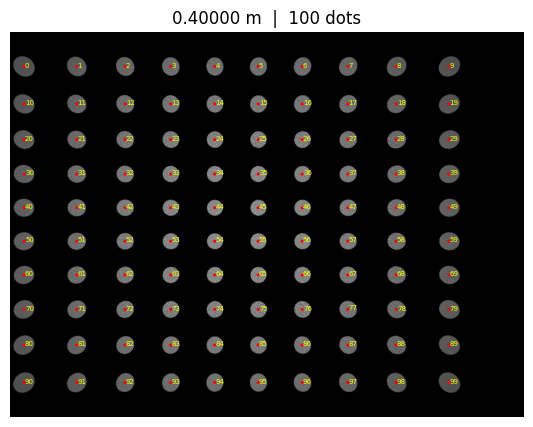

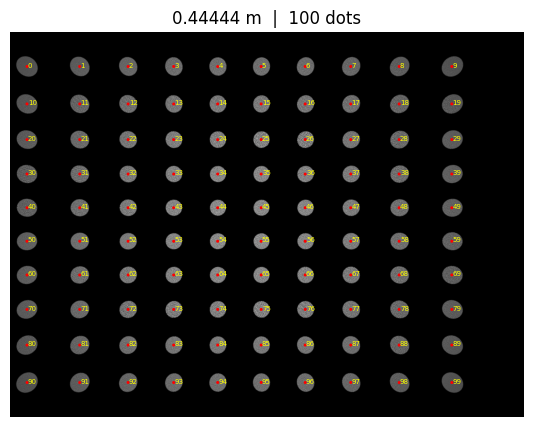

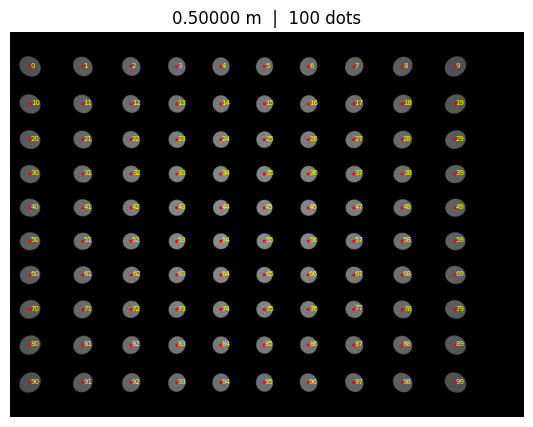

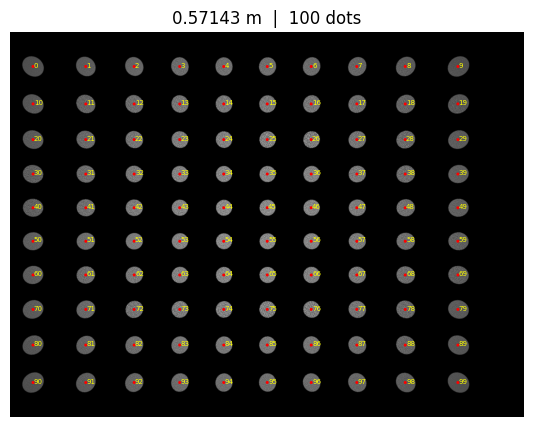

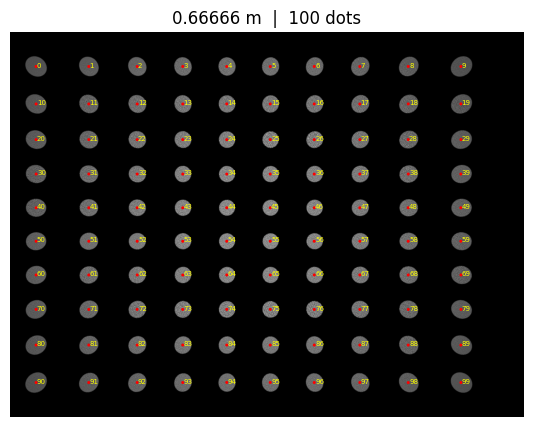

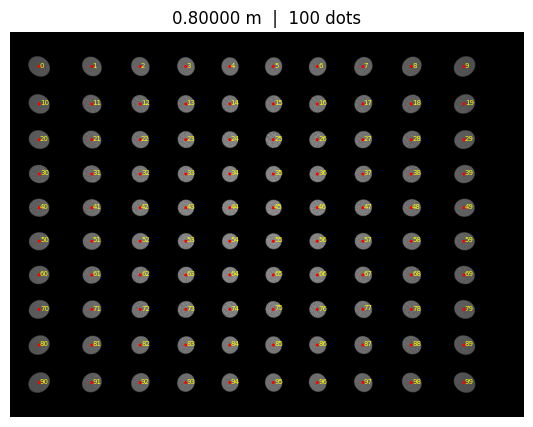

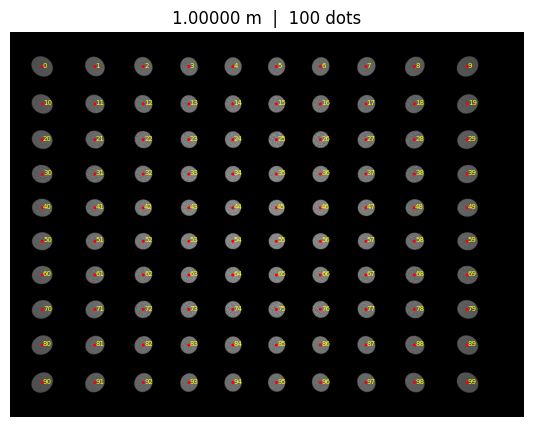

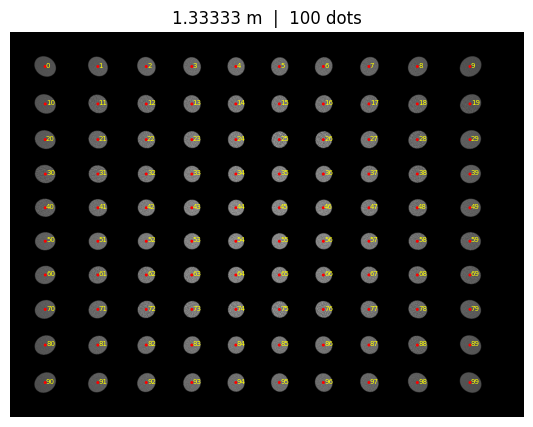

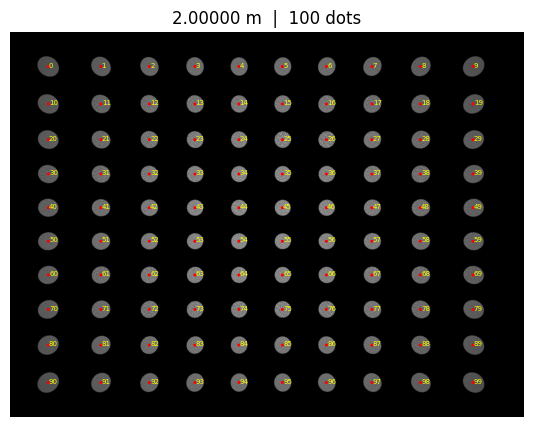

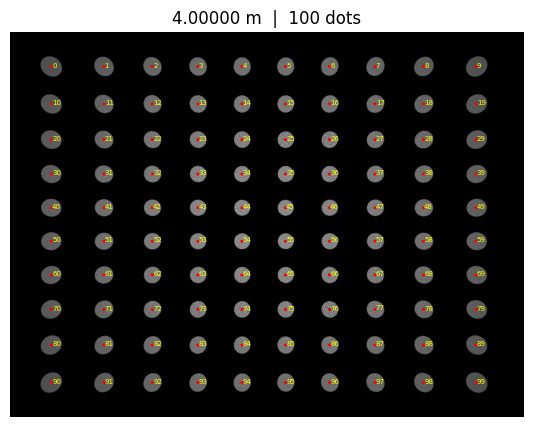

In [89]:
# Step 3: 3-D back-projection of calibration dots
BASELINE_GUESS = 3.0e-2   # initial transmitter x-offset estimate [m]

U, U_tx = dotCal.backproject_calibration_dots(
    subpixel_list, tof_paths,
    tof_mode="pcd", K=K,
    pcd_depth_mode="radial",
    baseline_guess=BASELINE_GUESS
)
print(f"U shape:    {U.shape}     (n_dots × n_dist × xyz)")
print(f"U_tx shape: {U_tx.shape}  (shifted by baseline_guess = {BASELINE_GUESS*100:.5f} cm)")

# ── Plot: SL images with detected dot IDs ──────────────────────────────
exr_files = sorted(sl_cal.glob("*.exr"),
                   key=lambda p: dotCal.parse_distance_from_name(p.name) or 999.0)
render_by_dist = {dotCal.parse_distance_from_name(p.name): str(p) for p in exr_files}

for j, dist in enumerate(cal_dists):
    exr = render_by_dist.get(dist)
    if exr is None:
        continue
    img = dotCal.read_image(exr)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(img, cmap="gray")
    for dot in subpixel_list[j]:
        ax.add_patch(plt.Circle((dot["x"], dot["y"]), 2,
                                edgecolor="red", facecolor="none", linewidth=1))
        ax.text(dot["x"] + 2, dot["y"] + 2, str(dot["id"]),
                fontsize=5, color="yellow")
    ax.set_title(f"{dist:.5f} m  |  {len(subpixel_list[j])} dots")
    ax.axis("off")
    calibration_figures.append((f"step3_dotids_{dist}m", fig))
    plt.show()

## Calibration Step 4: Baseline Estimation

Fit a 3-D line through each dot's multi-distance measurements (in U_tx space),
then find the least-squares intersection of all lines.  The x-component is the
correction to the initial baseline guess, giving AB.

Fitted 100 dot lines
LS intersection (U_tx):  [-5.99450797e-02 -2.01845241e-07  3.61503592e-04]
Baseline AB:  -2.99451 cm   →  B = [-0.02994508  0.          0.        ]
y, z of intersection (expect ≈ 0):  -0.00000, 0.00036


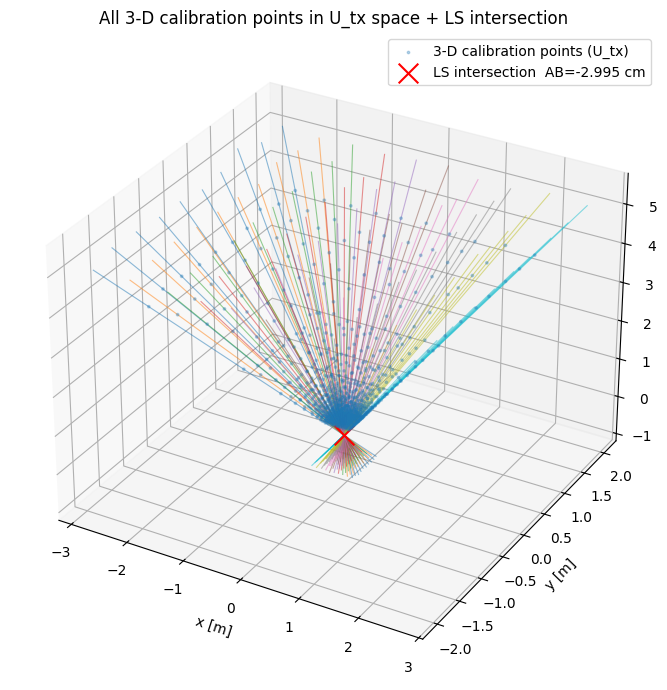

In [90]:
# Step 4: baseline estimation
SHOW_DOT_TRAILS = True   # connect same dots across distances with lines
EXTEND_FACTOR   = 0.3    # extend lines 30% beyond endpoints toward intersection

intersection, n_lines = dotCal.estimate_baseline(U_tx)
AB = BASELINE_GUESS + float(intersection[0])
B  = np.array([AB, 0.0, 0.0])

print(f"Fitted {n_lines} dot lines")
print(f"LS intersection (U_tx):  {intersection}")
print(f"Baseline AB:  {AB*100:.5f} cm   →  B = {B}")
print(f"y, z of intersection (expect ≈ 0):  "
      f"{float(intersection[1]):.5f}, {float(intersection[2]):.5f}")

# ── 3-D plot: points + lines + intersection ─────────────────────────────
all_pts = U_tx.reshape(-1, 3)
all_pts = all_pts[np.all(np.isfinite(all_pts), axis=1)]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(all_pts[:, 0], all_pts[:, 1], all_pts[:, 2],
           s=3, alpha=0.3, label="3-D calibration points (U_tx)")

if SHOW_DOT_TRAILS:
    cmap = plt.cm.tab10
    n_dots = U_tx.shape[0]
    for i in range(n_dots):
        pts = U_tx[i, :, :]
        valid = np.all(np.isfinite(pts), axis=1)
        if valid.sum() < 2:
            continue
        pts_v = pts[valid]
        # direction from farthest to nearest calibration point
        direction = pts_v[-1] - pts_v[0]
        extent = np.linalg.norm(direction)
        # extend beyond both endpoints
        start = pts_v[0] - EXTEND_FACTOR * direction
        end   = pts_v[-1] + EXTEND_FACTOR * direction
        extended = np.vstack([start[None, :], pts_v, end[None, :]])
        ax.plot(extended[:, 0], extended[:, 1], extended[:, 2],
                color=cmap(i % 10), alpha=0.5, linewidth=0.8)

ax.scatter(*intersection, s=200, marker="x", color="red",
           label=f"LS intersection  AB={AB*100:.3f} cm")
ax.set_title("All 3-D calibration points in U_tx space + LS intersection")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
plt.show()
calibration_figures.append(("step4_baseline_3d", fig))

## Calibration Step 5: Unit Vector Estimation

For each dot i, fit a unit direction vector V[i] by minimising the angle between
the fitted ray and each calibration point Q_ij = U_ij − B.

Unit vectors estimated: 100 / 100


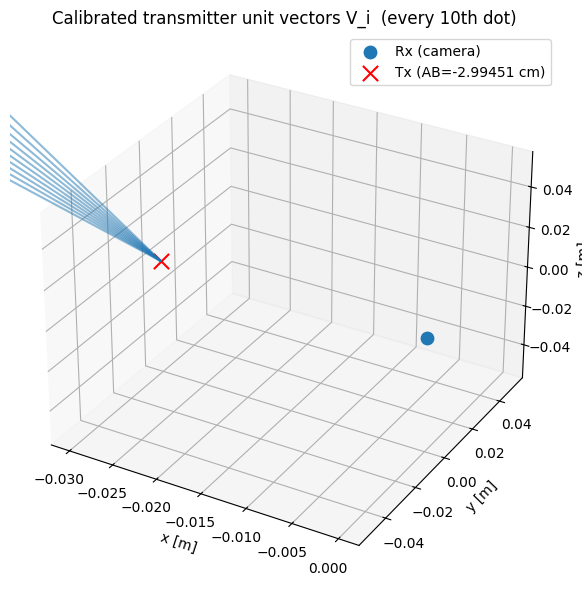

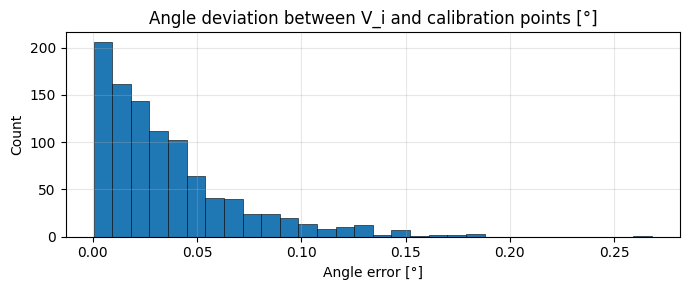

Median angle error: 0.02639°
Max    angle error: 0.26818°


In [91]:
# Step 5: unit vector estimation
V = dotCal.estimate_unit_vectors(U, AB)
V_valid = V[np.all(np.isfinite(V), axis=1)]
print(f"Unit vectors estimated: {len(V_valid)} / {V.shape[0]}")

# Angle-error diagnostics
angle_errs = []
for i in range(V.shape[0]):
    if not np.all(np.isfinite(V[i])):
        continue
    pts   = U[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    Q     = pts[valid] - B[None, :]
    Qn    = Q / (np.linalg.norm(Q, axis=1, keepdims=True) + 1e-12)
    angle_errs.extend(np.degrees(np.arccos(np.clip(Qn @ V[i], -1, 1))).tolist())

# ── Quiver plot ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter([0], [0], [0], s=80, marker="o", label="Rx (camera)")
ax.scatter([B[0]], [B[1]], [B[2]], s=120, marker="x", color="red", label=f"Tx (AB={AB*100:.5f} cm)")
for i in range(0, V.shape[0], 10):
    if not np.all(np.isfinite(V[i])):
        continue
    ax.quiver(B[0], B[1], B[2], V[i, 0], V[i, 1], V[i, 2],
              length=0.4, normalize=True, alpha=0.5)
ax.set_title("Calibrated transmitter unit vectors V_i  (every 10th dot)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step5_unit_vectors", fig))
plt.show()

# ── Angle-error histogram ─────────────────────────────────────────────
plt.figure(figsize=(7, 3))
plt.hist(np.array(angle_errs), bins=30, edgecolor="k", linewidth=0.4)
plt.title("Angle deviation between V_i and calibration points [°]")
plt.xlabel("Angle error [°]"); plt.ylabel("Count")
plt.grid(alpha=0.3); plt.tight_layout()
calibration_figures.append(("step5_angle_error_hist", plt.gcf()))
plt.show()

print(f"Median angle error: {np.median(angle_errs):.5f}°")
print(f"Max    angle error: {np.max(angle_errs):.5f}°")

## Save Calibration

Save all calibration data (V, B, K, subpixel_list, etc.) to a JSON file in  
`Calibrations/<name>/calibration.json`. Optionally save all calibration plots as PNGs.

In [39]:
import json as _json
from datetime import datetime as _dt

# ── User input ──────────────────────────────────────────────────────────
cal_name   = input("Calibration name: ").strip()
save_plots = input("Save calibration plots? (y/n): ").strip().lower() == "y"

assert cal_name, "Calibration name must not be empty."

# ── Output directory ────────────────────────────────────────────────────
cal_dir = Path.cwd().parent / "Calibrations" / cal_name
cal_dir.mkdir(parents=True, exist_ok=True)

# ── NaN-safe JSON serialization ─────────────────────────────────────────
def _sanitize(obj):
    """Recursively replace NaN/Inf with None for JSON compatibility."""
    if isinstance(obj, float):
        if np.isnan(obj) or np.isinf(obj):
            return None
        return obj
    if isinstance(obj, (np.floating,)):
        v = float(obj)
        return None if (np.isnan(v) or np.isinf(v)) else v
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return _sanitize(obj.tolist())
    if isinstance(obj, list):
        return [_sanitize(x) for x in obj]
    if isinstance(obj, dict):
        return {k: _sanitize(v) for k, v in obj.items()}
    return obj

cal_data = _sanitize({
    "metadata": {
        "created": _dt.now().isoformat(),
        "sl_cal_path": str(sl_cal),
        "tof_cal_path": str(tof_cal),
        "baseline_guess": BASELINE_GUESS,
        "subpixel_mode": "geometricCenter",
        "pcd_depth_mode": "radial",
        "pcd_unit_scale": 0.001,
        "fx": float(fx), "fy": float(fy),
        "cx": float(cx), "cy": float(cy),
    },
    "K": K.tolist(),
    "K_inv": K_inv.tolist(),
    "V": V.tolist(),
    "B": B.tolist(),
    "AB": float(AB),
    "BASELINE_GUESS": float(BASELINE_GUESS),
    "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": [[{"id": int(d["id"]), "x": float(d["x"]), "y": float(d["y"])}
                        for d in dists] for dists in subpixel_list],
    "U": U.tolist(),
})

cal_json_path = cal_dir / "calibration.json"
with open(cal_json_path, "w") as f:
    _json.dump(cal_data, f, indent=2)
print(f"Calibration data saved to {cal_json_path}")

# ── Save plots ──────────────────────────────────────────────────────────
if save_plots:
    for name, fig in calibration_figures:
        fig_path = cal_dir / f"{name}.png"
        fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved {len(calibration_figures)} plot(s) to {cal_dir}")
else:
    print("Plots not saved.")


KeyboardInterrupt: Interrupted by user

## Approach 1: Consistency Error  (Microsoft-Paper paper)

At test time, each detected dot is assigned to its closest calibration trail.
The trail is sampled at all calibration distances.  For each sample j along the
trail, both Z_ToF(j) and Z_triangulation(j) are computed.  The sample
j\* = argmin ε, with **ε = |1/Z_ToF − 1/Z_tri|**, is selected as the output depth.

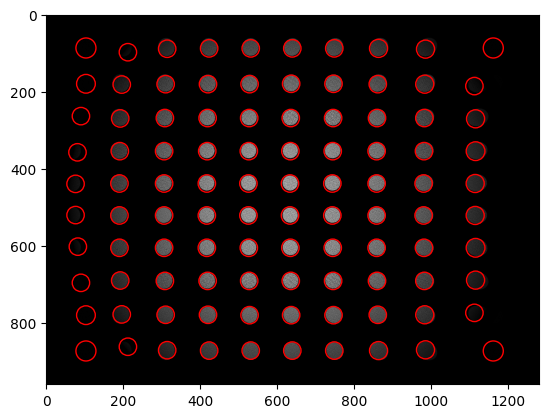

Detected dots in test SL: 100


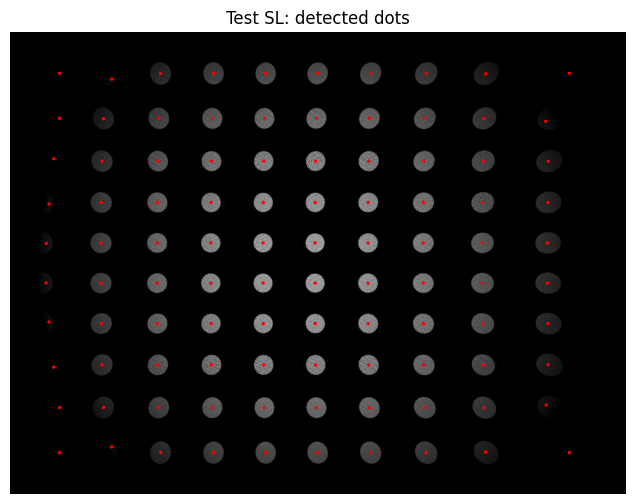

Processed 100 dots


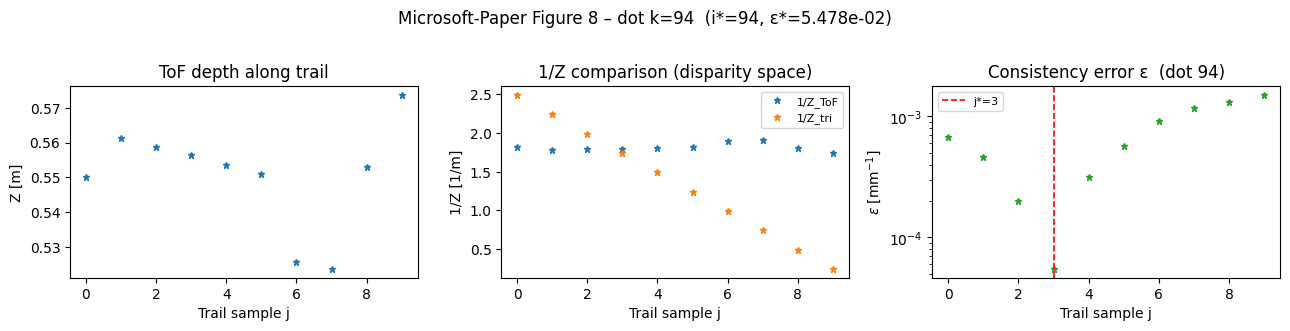

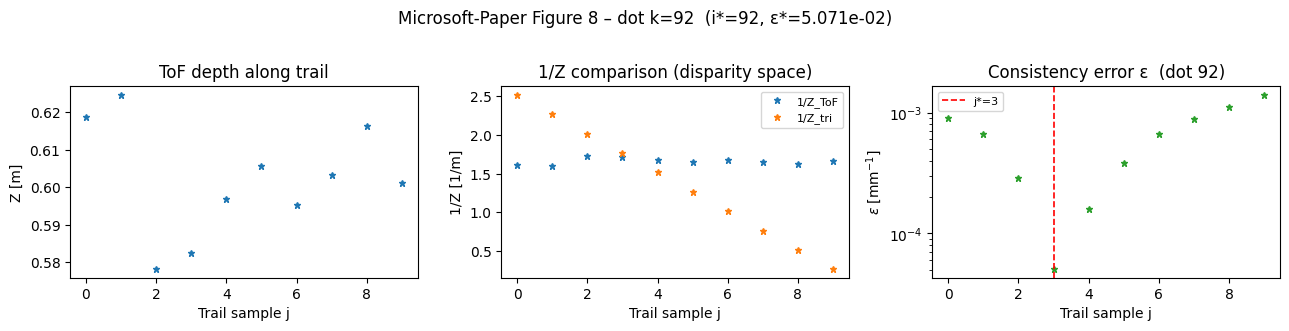

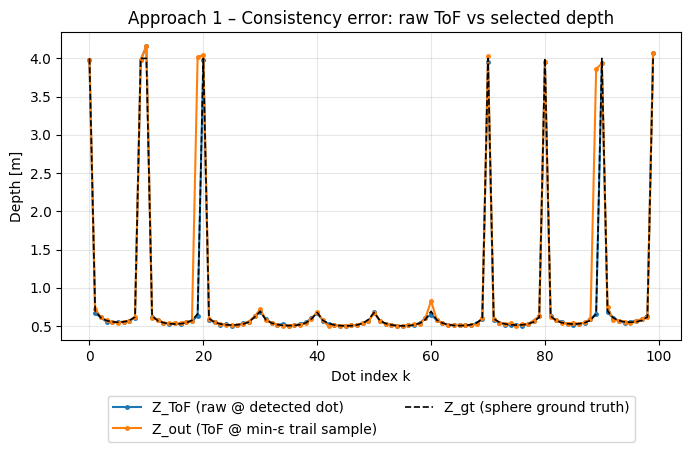

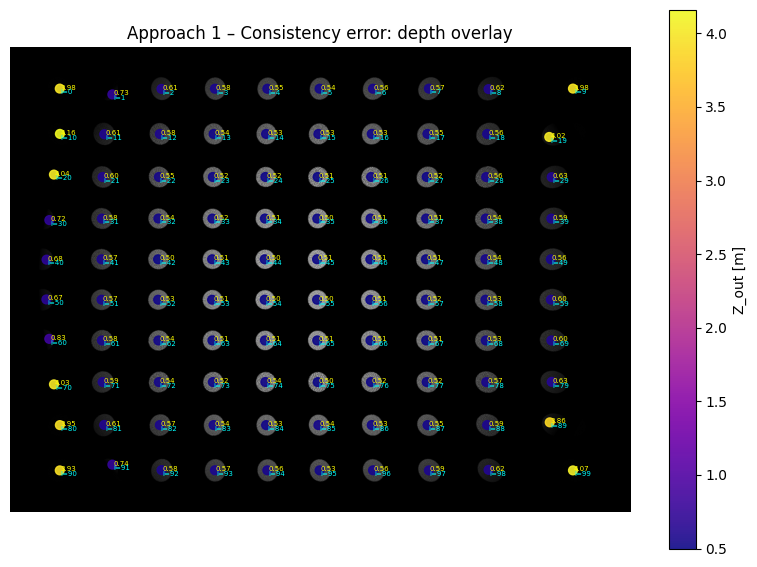

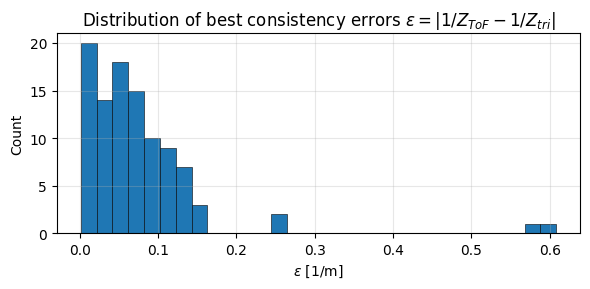

In [112]:
# ── Inputs ─────────────────────────────────────────────────────────────
SL_TEST      = str(test_dir / "SL_Sp_1m_On.exr")
TOF_TEST     = str(test_dir / "ToF_Sp_1m_On.pcd")
PCD_SCALE    = 0.001
EPS_THRESHOLD = None   # set a float to invalidate high-ε dots



# ── Load test scene ──────────────────────────────────────────────────────
trail_xy = dotCal.build_calibration_trails(subpixel_list)

tof_test   = dotCal.load_tof_pcd(TOF_TEST, unit_scale=PCD_SCALE, depth_mode="axial")
depth_map  = tof_test["depth_map"]
H, W       = depth_map.shape

#blobs_test, sl_gray = dotCal.detect_blobs(
#    SL_TEST, max_sigma=25, num_sigma=75, threshold=0.032, visualize=True
#)

if dots == 30:

    blobs_test, sl_gray = dotCal.detect_blobs(
            SL_TEST, max_sigma=3, num_sigma=5, min_sigma=3, threshold=0.006,add_synthetic_gaussian=False, visualize=True
        )
elif dots == 20:
    blobs_test, sl_gray = dotCal.detect_blobs(
            SL_TEST, max_sigma=5, num_sigma=2, min_sigma=3, threshold=0.0001,add_synthetic_gaussian=False, visualize=True
        )
else:
    blobs_test, sl_gray = dotCal.detect_blobs(
        SL_TEST, max_sigma=25, num_sigma=16, min_sigma=16, threshold=0.02,add_synthetic_gaussian=False, visualize=True
        )
_, subpix_test = dotCal.detect_subpixel_locations(
    blobs_test, sl_gray, mode="geometricCenter"
)
test_uv = np.array([[d["x"], d["y"]] for d in subpix_test], dtype=float)
print(f"Detected dots in test SL: {len(subpix_test)}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(sl_gray, cmap="gray")
for d in subpix_test:
    ax.add_patch(plt.Circle((d["x"], d["y"]), 2,
                            edgecolor="red", facecolor="none", linewidth=1))
ax.set_title("Test SL: detected dots"); ax.axis("off"); plt.show()



# ── Ground-truth configuration ───────────────────────────────────────────
# Wähle das GT-Modell passend zur geladenen Testszene:
#   "sphere" -> analytische Kugel + flacher Hintergrund (Sp_*-Szenen)
#   "mpi"  -> konkave V-Rinne / Raumecke (MPI_*-Szene)
#   None     -> keine Ground Truth
GT_SCENE = "sphere"          # "sphere" | "mpi" | None

# -- Kugel-Modell (Sp_*-Szenen) -------------------------------------------
SPHERE_CENTER = np.array([0.0, 0.0, 1.0])   # Kugelmittelpunkt [m]
SPHERE_RADIUS = 0.50                        # Kugelradius [m] (= diameter/2)
BACKGROUND_Z  = 4.0                         # flache Hintergrundwand bei z [m]

# -- MPI-Modell (konkave V-Rinne / Raumecke) (MPI_*-Szene), aus PBRT-Mesh ----------------------
# Querschnitt x-z: Kante (±half_w, edge_z) -> First (0, apex_z), y-invariant.
MPI_APEX_Z   = 1.025          # Firsttiefe bei x=0 [m]
MPI_HALF_W   = 0.4         # halbe Breite in x [m]
MPI_EDGE_Z   = 0.53           # Tiefe an den Rändern x=±half_w [m]
MPI_Y_RANGE  = (-3.0, 3.0)    # y-Ausdehnung der Flächen [m]
MPI_BG_Z     = None           # None -> Ebenen füllen ganzes FOV (kein Clip am Mesh-Rand); Zahl -> Mesh endet bei ±half_w, dahinter diese Tiefe


def ground_truth_sphere_depth(u, v, center, radius, K_inv,
                              depth_mode="axial", background_z=BACKGROUND_Z):
    """Ray-Sphere-Schnitt; Fallback auf flache Hintergrundwand bei z=background_z."""
    d = DotCalibration.cam_ray(u, v, K_inv)
    b = float(d @ center)
    c = float(center @ center) - radius ** 2
    disc = b * b - c
    if disc >= 0:
        s = b - np.sqrt(disc)                      # vordere Fläche = kleinere Wurzel
        if s <= 0:
            s = b + np.sqrt(disc)
        if s > 0:
            P = s * d
            return float(P[2]) if depth_mode == "axial" else float(np.linalg.norm(P))
    if background_z is None or d[2] <= 1e-9:
        return np.nan
    s = background_z / d[2]                         # s so, dass (s·d).z == background_z
    P = s * d
    return float(P[2]) if depth_mode == "axial" else float(np.linalg.norm(P))


def ground_truth_mpi_depth(u, v, K_inv, apex_z=MPI_APEX_Z, half_w=MPI_HALF_W,
                             edge_z=MPI_EDGE_Z, y_range=MPI_Y_RANGE,
                             background_z=MPI_BG_Z, depth_mode="axial"):
    """
    Konkave V-Rinne / Raumecke (MPI-Szene): zwei y-invariante Ebenen z = apex_z - k·|x|,
    k = (apex_z - edge_z)/half_w, gültig für |x| <= half_w und y in y_range.
    Ray-Ebenen-Schnitt, vorderster gültiger Treffer; sonst Hintergrund/NaN.
    """
    d = DotCalibration.cam_ray(u, v, K_inv)
    k = (apex_z - edge_z) / half_w
    best_s = None
    for sign in (+1.0, -1.0):                       # +1: rechte Ebene (x>=0), -1: linke (x<=0)
        denom = d[2] + sign * k * d[0]
        if abs(denom) < 1e-12:
            continue
        s = apex_z / denom
        if s <= 0:
            continue
        x = s * d[0]
        if sign * x < -1e-9:
            continue                            # falsche Halbebene
        if background_z is not None and abs(x) > half_w + 1e-9:
            continue                            # außerhalb endliches Mesh -> Hintergrund
        y = s * d[1]
        if y < y_range[0] or y > y_range[1]:
            continue
        if best_s is None or s < best_s:
            best_s = s
    if best_s is not None:
        P = best_s * d
        return float(P[2]) if depth_mode == "axial" else float(np.linalg.norm(P))
    if background_z is None or d[2] <= 1e-9:
        return np.nan
    s = background_z / d[2]
    P = s * d
    return float(P[2]) if depth_mode == "axial" else float(np.linalg.norm(P))


def ground_truth_depth(u, v):
    """Dispatcher: liefert Ground-truth-Tiefe (axial) je nach GT_SCENE."""
    if GT_SCENE == "sphere":
        return ground_truth_sphere_depth(u, v, SPHERE_CENTER, SPHERE_RADIUS, K_inv)
    if GT_SCENE == "mpi":
        return ground_truth_mpi_depth(u, v, K_inv)
    return np.nan


# ── ToF depth sampler ────────────────────────────────────────────────────
def sample_tof_depth(u, v, search_radius=3):
    """Sample axial ToF depth from organised depth_map with local fill."""
    for r in range(search_radius + 1):
        for dv in range(-r, r + 1):
            for du in range(-r, r + 1):
                u2, v2 = int(round(u)) + du, int(round(v)) + dv
                if 0 <= u2 < W and 0 <= v2 < H:
                    z = depth_map[v2, u2]
                    if np.isfinite(z) and z > 1e-6:
                        return float(z), float(np.hypot(du, dv))
    return 1e-9, np.inf


# Trail KD-trees for fast dot-to-trail assignment
trail_trees = [cKDTree(trail_xy[:, i, :]) for i in range(trail_xy.shape[1])]
n_dist = trail_xy.shape[0]


# ── Run Microsoft-Paper algorithm ──────────────────────────────────────────────────
results = []

for k, (uu, vv) in enumerate(test_uv):
    # a) assign dot to calibration ray (nearest trail)
    best_i, best_dist = min(
        enumerate(trail_trees),
        key=lambda t: t[1].query([uu, vv], k=1)[0]
    )
    best_dist = trail_trees[best_i].query([uu, vv], k=1)[0]

    # b) compute ε along all trail samples
    Z_tri_arr = np.empty(n_dist)
    Z_tof_arr = np.empty(n_dist)
    eps_arr   = np.empty(n_dist)

    for j in range(n_dist):
        uij = float(trail_xy[j, best_i, 0])
        vij = float(trail_xy[j, best_i, 1])
        Z_tri = dotCal.triangulate_depth(uij, vij, V[best_i], B, K_inv)
        Z_tof, _ = sample_tof_depth(uij, vij)
        Z_tri_arr[j] = max(Z_tri, 1e-9)
        Z_tof_arr[j] = max(Z_tof, 1e-9)
        eps_arr[j]   = dotCal.consistency_error(Z_tof_arr[j], Z_tri_arr[j])

    # c) & d) select min-ε sample
    j_best   = int(np.argmin(eps_arr))
    Z_raw, _ = sample_tof_depth(uu, vv)
    Z_out    = float(Z_tof_arr[j_best])
    if EPS_THRESHOLD is not None and float(eps_arr[j_best]) > EPS_THRESHOLD:
        Z_out = Z_raw
    Z_gt = ground_truth_depth(uu, vv)
    results.append(dict(
        k=k, u=float(uu), v=float(vv),
        Z_raw=Z_raw, Z_out=Z_out,
        Z_gt=Z_gt,
        i_best=best_i, j_best=j_best,
        eps_best=float(eps_arr[j_best]),
        eps_curve=eps_arr.copy(),
        Z_tri_curve=Z_tri_arr.copy(),
        Z_tof_curve=Z_tof_arr.copy(),
    ))

print(f"Processed {len(results)} dots")


# ── ε-curve plots (best and worst dot) ──────────────────────────────────
eps_all = np.array([r["eps_best"] for r in results], float)
for label, k_ex in [("dot 94", 94),     # or in [("best ε", int(np.argmin(eps_all))),
                     ("dot 92", 92)]:  # or ("worst ε", int(np.argmax(eps_all)))]:
    ex  = results[k_ex]
    x   = np.arange(n_dist)
    eps_plot = ex["eps_curve"] * 1e-3   # 1/m → 1/mm (paper scale)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    axes[0].plot(x, ex["Z_tof_curve"], "*", markersize=5)
    axes[0].set_title("ToF depth along trail")
    axes[0].set_xlabel("Trail sample j"); axes[0].set_ylabel("Z [m]")

    axes[1].plot(x, 1 / ex["Z_tof_curve"], "*", markersize=5, label="1/Z_ToF")
    axes[1].plot(x, 1 / ex["Z_tri_curve"], "*", markersize=5, label="1/Z_tri")
    axes[1].set_title("1/Z comparison (disparity space)")
    axes[1].set_xlabel("Trail sample j"); axes[1].set_ylabel("1/Z [1/m]")
    axes[1].legend(fontsize=8)

    axes[2].semilogy(x, eps_plot, "*", markersize=5, color="C2")
    axes[2].axvline(ex["j_best"], color="red", linewidth=1.2, linestyle="--",
                    label=f"j*={ex['j_best']}")
    axes[2].set_title(f"Consistency error ε  ({label})")
    axes[2].set_xlabel("Trail sample j")
    axes[2].set_ylabel(r"$\varepsilon$ [mm$^{-1}$]")
    axes[2].legend(fontsize=8)

    plt.suptitle(
        f"Microsoft-Paper Figure 8 – dot k={ex['k']}  (i*={ex['i_best']}, "
        f"ε*={ex['eps_best']:.3e})", y=1.02
    )
    plt.tight_layout(); plt.show()


# ── Depth per dot: raw vs approach 1 ────────────────────────────────────
plt.figure(figsize=(8, 4))
#plt.ylim(0.25,1.25)
plt.plot([r["k"] for r in results], [r["Z_raw"] for r in results],
         ".-", markersize=5, label="Z_ToF (raw @ detected dot)")
plt.plot([r["k"] for r in results], [r["Z_out"] for r in results],
         ".-", markersize=5, label="Z_out (ToF @ min-ε trail sample)")
plt.plot([r["k"] for r in results], [r["Z_gt"] for r in results],          # <── NEU                
        "k--", linewidth=1.2, label=f"Z_gt ({GT_SCENE} ground truth)")
plt.title("Approach 1 – Consistency error: raw ToF vs selected depth")
plt.xlabel("Dot index k"); plt.ylabel("Depth [m]")
#plt.xlim(0,100)
#plt.legend(); plt.grid(alpha=0.3); plt.show()
plt.legend(bbox_to_anchor=(0.5, -0.18), loc="upper center", borderaxespad=0, ncol=2); plt.grid(alpha=0.3)


# ── Depth overlay on SL image ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(sl_gray, cmap="gray")
xs = np.array([r["u"] for r in results])
ys = np.array([r["v"] for r in results])
zs = np.array([r["Z_out"] for r in results])
sc = ax.scatter(xs, ys, s=40, c=zs, cmap="plasma", alpha=0.9)
plt.colorbar(sc, ax=ax, label="Z_out [m]")
for r in results:
    ax.text(r["u"] + 2, r["v"] + 2,  f'{r["Z_out"]:.2f}', fontsize=5, color="yellow")
    ax.text(r["u"] + 2, r["v"] + 12, f'i={r["i_best"]}',  fontsize=5, color="cyan")
ax.set_title("Approach 1 – Consistency error: depth overlay")
ax.axis("off"); plt.show()


# ── ε histogram ─────────────────────────────────────────────────────────
plt.figure(figsize=(6, 3))
plt.hist(eps_all, bins=30, edgecolor="k", linewidth=0.4)
if EPS_THRESHOLD:
    plt.axvline(EPS_THRESHOLD, color="red", label=f"threshold={EPS_THRESHOLD:.3e}")
    plt.legend()
plt.title(r"Distribution of best consistency errors $\varepsilon = |1/Z_{ToF} - 1/Z_{tri}|$")
plt.xlabel(r"$\varepsilon$ [1/m]"); plt.ylabel("Count")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Approach 2: Maximum Likelihood Fusion  (Agresti & Zanuttigh, ECCV 2018)

ToF and SL (triangulation) depth estimates are combined via maximum likelihood
using spatially-weighted mixture-of-Gaussians likelihoods derived from per-pixel
noise variance models.  The fused depth maximises the joint log-likelihood.

ToF valid: 100 / 100   range: 0.50–4.16 m
SL  valid: 100 / 100   range: 0.50–4.23 m
Fused valid: 100 / 100   range: 0.50–4.12 m


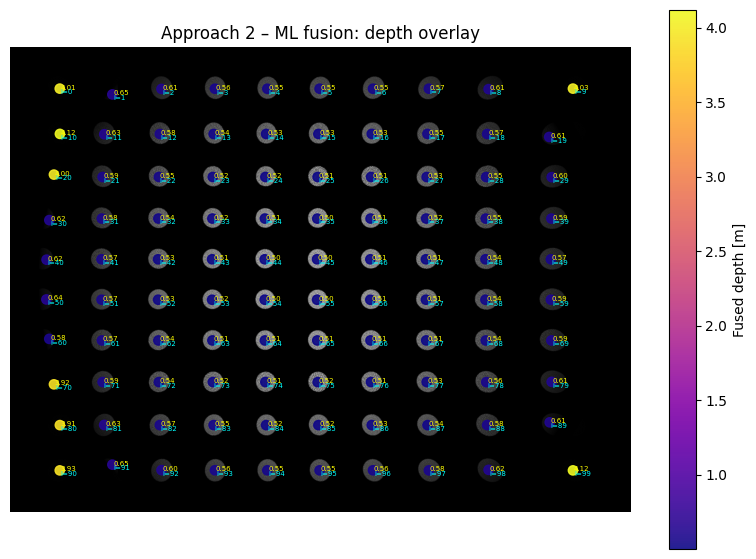

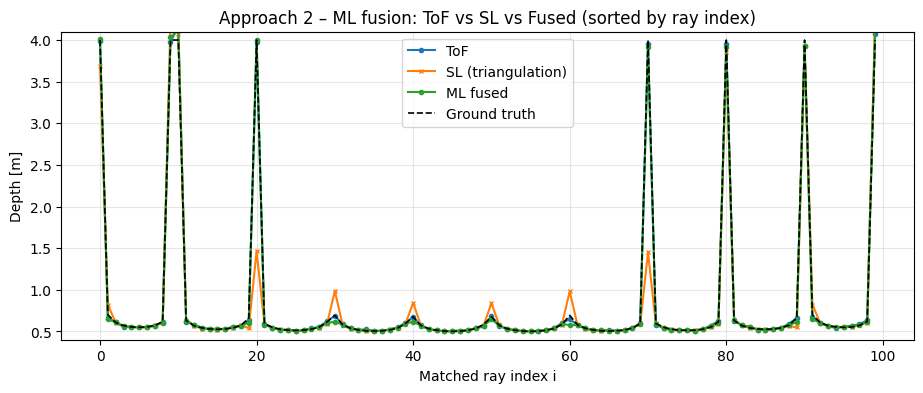

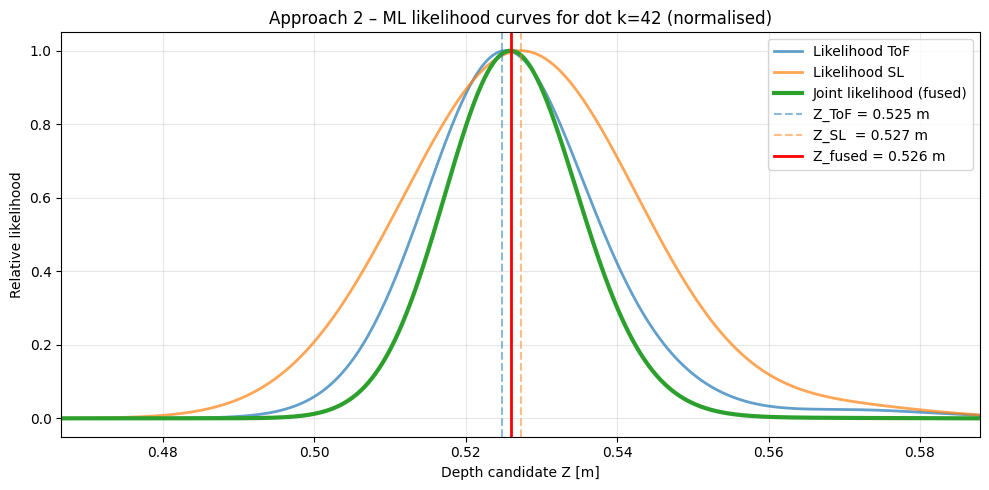

In [114]:
# Uses sl_gray, depth_map, trail_xy, test_uv, V, B, K_inv from Approach 1 cell.

# ── Settings ────────────────────────────────────────────────────────────
MAX_TOF_PIX_DIST = 6.0
TOF_FILL_WIN     = 2
TRAIL_SOFT_SCALE = 6.0    # px – inflates σ_SL when dot is far from trail
wh               = 3      # spatial neighbourhood half-width
Z_CAND_N         = 400    # number of depth candidates for ML search

# ── Load test ToF with 3-D point map ────────────────────────────────────
tof_test_ml = dotCal.load_tof_pcd(TOF_TEST, unit_scale=PCD_SCALE, depth_mode="axial")
depth_map_ml = tof_test_ml["depth_map"]
points_map   = tof_test_ml["points_3d"].reshape(H, W, 3)


# ── Samplers ─────────────────────────────────────────────────────────────
def sample_tof_ml(u, v):
    """Return (range, pixel-distance) from organised depth map."""
    uu, vv = int(round(u)), int(round(v))
    for r in range(TOF_FILL_WIN + 1):
        for dv in range(-r, r + 1):
            for du in range(-r, r + 1):
                u2, v2 = uu + du, vv + dv
                if 0 <= u2 < W and 0 <= v2 < H:
                    z = depth_map_ml[v2, u2]
                    if np.isfinite(z) and z > 1e-6:
                        return float(z), float(np.hypot(du, dv))
    return np.nan, np.inf




# ── Assign trail and compute per-dot depths ──────────────────────────────
test_ztof = np.full(len(test_uv), np.nan)
test_nnpx = np.full(len(test_uv), np.nan)

for k, (uu, vv) in enumerate(test_uv):
    z, dpx          = sample_tof_ml(uu, vv)
    test_ztof[k]    = z
    test_nnpx[k]    = dpx

z_sl      = np.full(len(test_uv), np.nan)
i_best_ml = np.full(len(test_uv), -1, int)
trail_d   = np.full(len(test_uv), np.nan)

for k, (uu, vv) in enumerate(test_uv):
    i, dpx = min(
        enumerate(trail_trees),
        key=lambda t: t[1].query([uu, vv], k=1)[0]
    )
    dpx = trail_trees[i].query([uu, vv], k=1)[0]
    i_best_ml[k] = i
    trail_d[k]   = dpx
    z = dotCal.triangulate_depth(uu, vv, V[i], B, K_inv)
    if np.isfinite(z) and z > 1e-6:
        z_sl[k] = z

print(f"ToF valid: {int(np.sum(np.isfinite(test_ztof)))} / {len(test_uv)}",
      f"  range: {np.nanmin(test_ztof):.2f}–{np.nanmax(test_ztof):.2f} m")
print(f"SL  valid: {int(np.sum(np.isfinite(z_sl)))} / {len(test_uv)}",
      f"  range: {np.nanmin(z_sl):.2f}–{np.nanmax(z_sl):.2f} m")


# ── Uncertainty models ───────────────────────────────────────────────────
def robust_sigma(vals):
    vals = np.asarray(vals, float)
    vals = vals[np.isfinite(vals)]
    if vals.size < 3:
        return np.nan
    return 1.4826 * np.median(np.abs(vals - np.median(vals)))

sigma_tof = np.full(len(test_uv), np.nan)
sigma_sl  = np.full(len(test_uv), np.nan)

for k, (uu, vv) in enumerate(test_uv):
    if np.isfinite(test_ztof[k]) and test_ztof[k] > 1e-6:
        ui, vi = int(round(uu)), int(round(vv))
        r = 3
        patch = depth_map_ml[max(0, vi-r):vi+r+1, max(0, ui-r):ui+r+1].ravel()
        s_loc = robust_sigma(patch)
        if not np.isfinite(s_loc):
            s_loc = 0.02
        sigma_tof[k] = max(0.01, s_loc + 0.02 * (test_nnpx[k] / max(MAX_TOF_PIX_DIST, 1e-6))**2)

    if np.isfinite(z_sl[k]) and z_sl[k] > 1e-6:
        base = 0.01 + 0.06 * (z_sl[k] / 4.0)**2
        if np.isfinite(trail_d[k]):
            base *= 1.0 + (trail_d[k] / max(TRAIL_SOFT_SCALE, 1e-6))**2
        sigma_sl[k] = max(0.01, base)


# ── ML Fusion (Agresti eq. 16-17) ───────────────────────────────────────
dot_tree = cKDTree(test_uv)
if len(test_uv) >= 5:
    dd, _ = dot_tree.query(test_uv, k=2)
    sigma_s_px = 0.5 * np.median(dd[:, 1])
else:
    sigma_s_px = 10.0


def log_mog_likelihood(Zcand, depths, sigmas, weights):
    """Log mixture-of-Gaussians likelihood over depth candidates."""
    m = np.isfinite(depths) & np.isfinite(sigmas) & (sigmas > 1e-9) & (weights > 0)
    if not np.any(m):
        return np.full_like(Zcand, -np.inf)
    d, s, w = depths[m], sigmas[m], weights[m]
    log_pref = np.log(np.maximum(w, 1e-12)) - np.log(s)
    out = np.empty(len(Zcand))
    for t, Z0 in enumerate(Zcand):
        lc  = log_pref - 0.5 * ((d - Z0) / s)**2
        mx  = np.max(lc)
        out[t] = mx + np.log(np.sum(np.exp(lc - mx)) + 1e-12)
    return out


knn_patch = (2 * wh + 1)**2
z_fus     = np.full(len(test_uv), np.nan)

for k in range(len(test_uv)):
    zt, zs = test_ztof[k], z_sl[k]
    st, ss = sigma_tof[k], sigma_sl[k]

    if np.isfinite(zs) and not np.isfinite(zt):
        z_fus[k] = float(zs); continue
    if np.isfinite(zt) and not np.isfinite(zs):
        z_fus[k] = float(zt); continue
    if not (np.isfinite(zt) and np.isfinite(zs) and np.isfinite(st) and np.isfinite(ss)):
        continue

    dnn, nn_idx = dot_tree.query(test_uv[k], k=min(knn_patch, len(test_uv)))
    w_sp = np.exp(-0.5 * (dnn / max(sigma_s_px, 1e-6))**2)

    zmin = max(1e-4, min(zt - 3*st, zs - 3*ss))
    zmax = max(zt + 3*st, zs + 3*ss)
    if not (np.isfinite(zmin) and np.isfinite(zmax)) or zmax <= zmin:
        continue

    Zcand   = np.linspace(zmin, zmax, Z_CAND_N)
    ll_tof  = log_mog_likelihood(Zcand, test_ztof[nn_idx], sigma_tof[nn_idx], w_sp)
    ll_sl   = log_mog_likelihood(Zcand, z_sl[nn_idx],  sigma_sl[nn_idx],  w_sp)
    z_fus[k] = float(Zcand[int(np.argmax(ll_tof + ll_sl))])

valid = np.isfinite(z_fus)
print(f"Fused valid: {int(np.sum(valid))} / {len(test_uv)}",
      f"  range: {np.nanmin(z_fus):.2f}–{np.nanmax(z_fus):.2f} m")


# ── Depth overlay ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(sl_gray, cmap="gray")
xs, ys = test_uv[:, 0], test_uv[:, 1]
sc = ax.scatter(xs[valid], ys[valid], s=45, c=z_fus[valid], cmap="plasma", alpha=0.9)
plt.colorbar(sc, ax=ax, label="Fused depth [m]")
for k in np.where(valid)[0]:
    ax.text(xs[k] + 2, ys[k] + 2,  f"{z_fus[k]:.2f}", fontsize=5, color="yellow")
    ax.text(xs[k] + 2, ys[k] + 12, f"i={i_best_ml[k]}", fontsize=5, color="cyan")
ax.set_title("Approach 2 – ML fusion: depth overlay"); ax.axis("off"); plt.show()


# ── Ground truth at detected dots ────────────────────────────────────────
z_gt = np.array([ground_truth_depth(uu, vv) for uu, vv in test_uv])

# ── Per-dot depth comparison ─────────────────────────────────────────────
m = (i_best_ml >= 0) & (np.isfinite(test_ztof) | np.isfinite(z_sl) | np.isfinite(z_fus))
order = np.argsort(i_best_ml[m])
x = i_best_ml[m][order]

plt.figure(figsize=(11, 4))
mt = np.isfinite(test_ztof[m][order])
ms = np.isfinite(z_sl[m][order])
mf = np.isfinite(z_fus[m][order])
plt.plot(x[mt], test_ztof[m][order][mt], "o-", markersize=3, label="ToF")
plt.plot(x[ms], z_sl[m][order][ms],       "x-", markersize=3, label="SL (triangulation)")
plt.plot(x[mf], z_fus[m][order][mf],      ".-", markersize=6, label="ML fused")
mg = np.isfinite(z_gt[m][order])
plt.plot(x[mg], z_gt[m][order][mg], "k--", linewidth=1.2, label="Ground truth")
plt.xlabel("Matched ray index i"); plt.ylabel("Depth [m]")
plt.ylim(0.4, 4.1)
plt.title("Approach 2 – ML fusion: ToF vs SL vs Fused (sorted by ray index)")
plt.grid(alpha=0.3); plt.legend(); plt.show()


# ── Likelihood visualisation for one example dot ─────────────────────────
valid_k = [k for k in range(len(test_uv))
           if np.isfinite(test_ztof[k]) and np.isfinite(z_sl[k]) and np.isfinite(z_fus[k])]

if valid_k:
    k_ex = valid_k[min(42, len(valid_k) - 1)]
    zt, zs = test_ztof[k_ex], z_sl[k_ex]
    st, ss = sigma_tof[k_ex], sigma_sl[k_ex]

    dnn, nn_idx = dot_tree.query(test_uv[k_ex], k=min(knn_patch, len(test_uv)))
    w_sp = np.exp(-0.5 * (dnn / max(sigma_s_px, 1e-6))**2)

    zmin_p = max(1e-4, min(zt - 4*st, zs - 4*ss))
    zmax_p = max(zt + 4*st, zs + 4*ss)
    Zp     = np.linspace(zmin_p, zmax_p, 500)

    ll_t = log_mog_likelihood(Zp, test_ztof[nn_idx], sigma_tof[nn_idx], w_sp)
    ll_s = log_mog_likelihood(Zp, z_sl[nn_idx],  sigma_sl[nn_idx],  w_sp)
    ll_j = ll_t + ll_s

    prob_t = np.exp(ll_t - np.max(ll_t))
    prob_s = np.exp(ll_s - np.max(ll_s))
    prob_j = np.exp(ll_j - np.max(ll_j))
    z_max  = float(Zp[int(np.argmax(prob_j))])

    plt.figure(figsize=(10, 5))
    plt.plot(Zp, prob_t, label="Likelihood ToF",      color="C0", linewidth=2, alpha=0.7)
    plt.plot(Zp, prob_s, label="Likelihood SL",       color="C1", linewidth=2, alpha=0.7)
    plt.plot(Zp, prob_j, label="Joint likelihood (fused)", color="C2", linewidth=3)
    plt.axvline(zt,    color="C0", linestyle="--", alpha=0.5, label=f"Z_ToF = {zt:.3f} m")
    plt.axvline(zs,    color="C1", linestyle="--", alpha=0.5, label=f"Z_SL  = {zs:.3f} m")
    plt.axvline(z_max, color="red", linewidth=2, label=f"Z_fused = {z_max:.3f} m")
    plt.title(f"Approach 2 – ML likelihood curves for dot k={k_ex} (normalised)")
    plt.xlabel("Depth candidate Z [m]"); plt.ylabel("Relative likelihood")
    plt.legend(loc="upper right"); plt.grid(alpha=0.3)
    plt.xlim([zmin_p, zmax_p]); plt.tight_layout(); plt.show()

## Approach 3: Active Brightness Trail  (Microsoft-Paper)

Approach 3 is implemented here as an **epipolar-line scan**. For this setup, the
calibration trails are nearly horizontal, so the active-brightness search is done
on image rows rather than on an interpolated pixel-span or distance-domain curve.

Two row-selection schemes are compared:
- one row per projector grid row (diagnostic only),
- one row per matched calibration dot (used for the actual scan).

The algorithm is:
1. Assign the detected dot to the nearest calibration trail / projector ray `V[i]`
2. Select the epipolar row from that dot's own calibration trail
3. Detect active-brightness peaks on that full image row
4. Evaluate `epsilon = |1/Z_{ToF} - 1/Z_{tri}|` at each row peak
5. Select the peak with minimum `epsilon`
6. Refine the selected column with a wider quadratic fit
7. Output the triangulated depth at `(u_sub, row)`

Fallback to all row columns is available only as an explicit debugging option and
is disabled by default.


Trail v-range (px):  mean=0.125  max=0.242  std=0.042
  ✓ All trails stay within 1 px vertically — horizontal epipolar assumption valid.
Per-dot vs grid-row row delta (px):  mean=0.080  max=1.000  >=0.5px=8  >=1px=8
Grid-row epipolar rows: [85, 179, 268, 354, 438, 521, 605, 691, 780, 874]
Scanned 12 unique rows — 12 have brightness peaks, total peaks: 242
Approach 3: processed 100 dots  (0 used fallback, 0 rejected by gates)


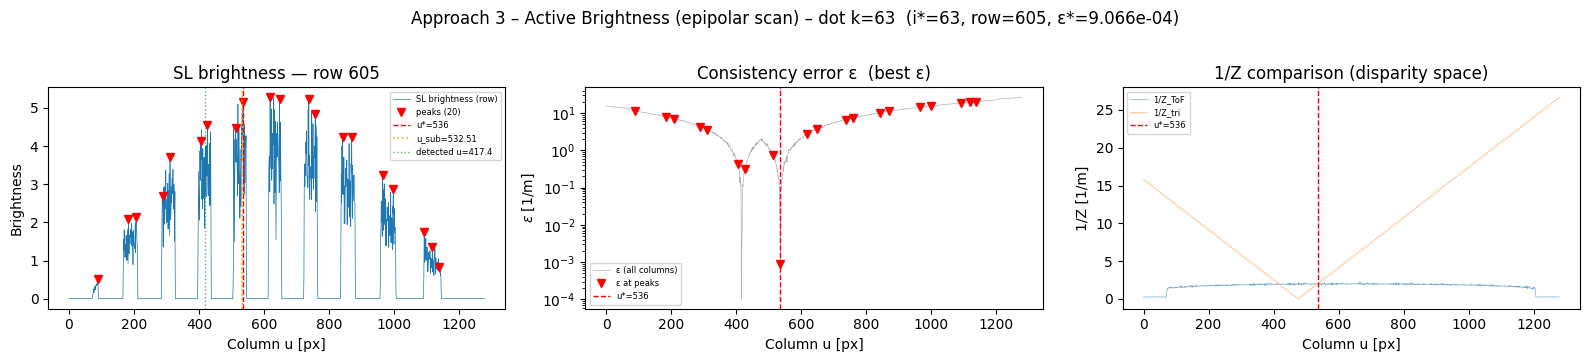

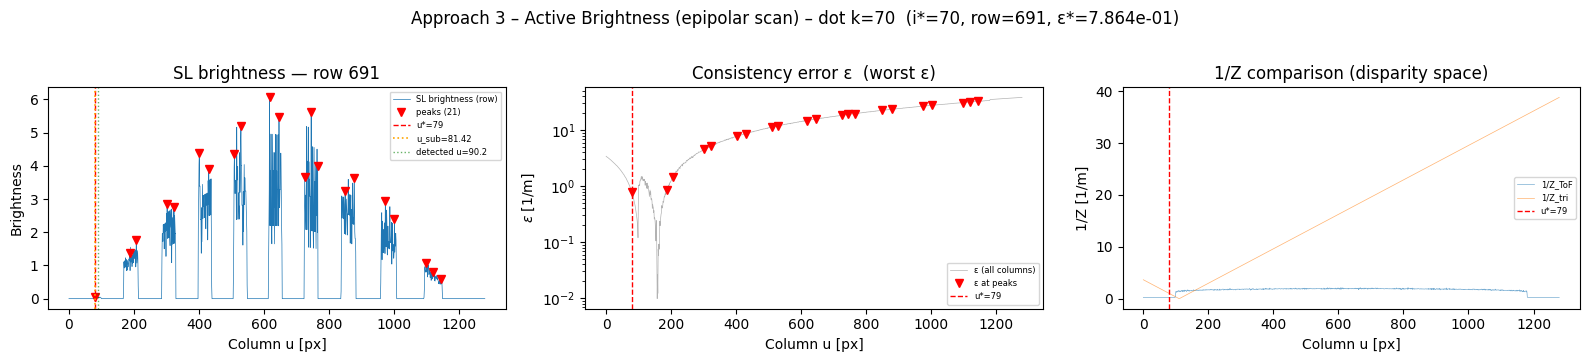

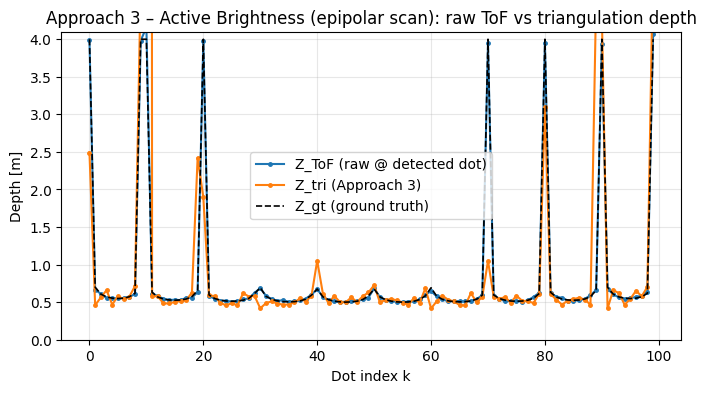

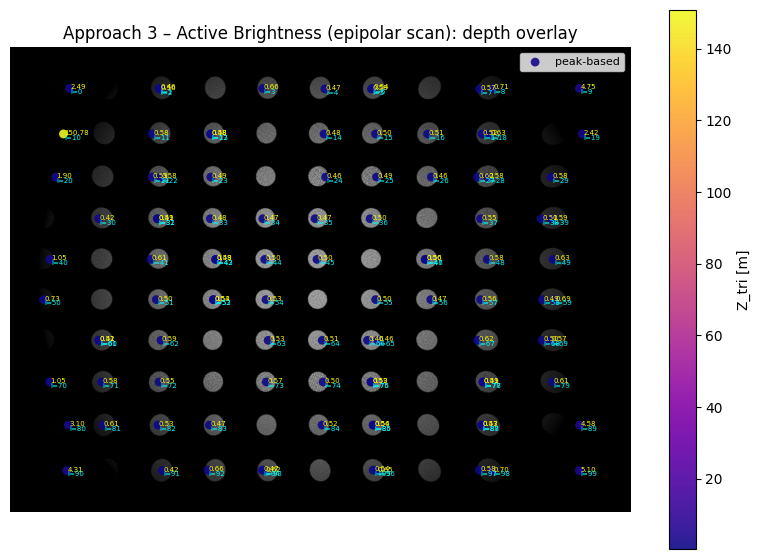

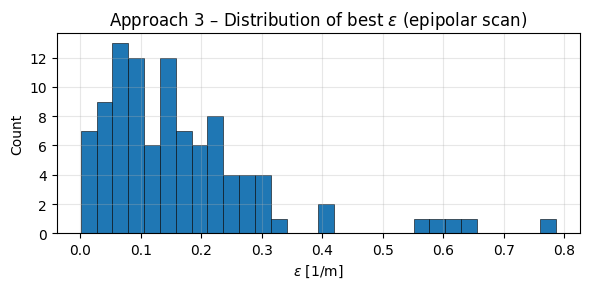

In [115]:
# Reuses from Approach 1: sl_gray, depth_map, trail_xy, trail_trees, test_uv,
#   subpix_test, V, B, K_inv, sample_tof_depth, n_dist, H, W

# ── Configurable gates (set to float to enable, None to disable) ────────
PEAK_SNR_MIN     = None   # e.g. 3.0 — reject if peak SNR < threshold
EPS_THRESHOLD_AB = None   # e.g. 0.5 — reject if best ε > threshold
USE_FALLBACK     = False  # True: allow min-ε over all columns (not paper-conform)
                          # False: only use brightness peaks (paper-conform)
HALF_WIN         = 5     # half-width for wider quadratic sub-pixel refinement
GRID_COLS        = dots

# ── Step 1: Derive diagnostic epipolar rows from calibration ────────────
n_grid_rows = trail_xy.shape[1] // GRID_COLS
epipolar_rows_grid = np.empty(n_grid_rows, dtype=int)
for gr in range(n_grid_rows):
    dot_indices = range(gr * GRID_COLS, (gr + 1) * GRID_COLS)
    v_coords = trail_xy[:, dot_indices, 1]
    epipolar_rows_grid[gr] = int(round(np.nanmean(v_coords)))
epipolar_rows_grid = np.clip(epipolar_rows_grid, 0, H - 1)
dot_to_grid_row = np.array([i // GRID_COLS for i in range(trail_xy.shape[1])])

# Per-dot row is used for the actual scan
epipolar_rows_dot = np.empty(trail_xy.shape[1], dtype=int)
for i in range(trail_xy.shape[1]):
    epipolar_rows_dot[i] = int(round(np.nanmean(trail_xy[:, i, 1])))
epipolar_rows_dot = np.clip(epipolar_rows_dot, 0, H - 1)

v_ranges = np.array([np.ptp(trail_xy[:, i, 1]) for i in range(trail_xy.shape[1])])
print(f"Trail v-range (px):  mean={np.mean(v_ranges):.3f}  "
      f"max={np.max(v_ranges):.3f}  std={np.std(v_ranges):.3f}")
if np.max(v_ranges) < 1.0:
    print("  ✓ All trails stay within 1 px vertically — horizontal epipolar assumption valid.")
else:
    print(f"  ⚠ {np.sum(v_ranges >= 1.0)} dot(s) exceed 1 px v-range — "
          f"horizontal assumption may be inaccurate for those dots.")

row_deltas = np.abs(epipolar_rows_dot - epipolar_rows_grid[dot_to_grid_row])
print(f"Per-dot vs grid-row row delta (px):  mean={np.mean(row_deltas):.3f}  "
      f"max={np.max(row_deltas):.3f}  >=0.5px={np.sum(row_deltas >= 0.5)}  "
      f">=1px={np.sum(row_deltas >= 1.0)}")

rows_to_scan = np.unique(np.concatenate([epipolar_rows_grid, epipolar_rows_dot]))
row_peaks = {}
for row in rows_to_scan:
    row_signal = sl_gray[row, :]
    row_max = np.max(row_signal)
    if row_max < 1e-12:
        continue
    pks, _ = scipy.signal.find_peaks(row_signal, prominence=0.001 * row_max, distance=20)
    if len(pks) > 0:
        row_peaks[int(row)] = pks

print(f"Grid-row epipolar rows: {epipolar_rows_grid.tolist()}")
print(f"Scanned {len(rows_to_scan)} unique rows — {len(row_peaks)} have brightness peaks, "
      f"total peaks: {sum(len(p) for p in row_peaks.values())}")

# ── Run Active Brightness algorithm (epipolar-line scanning) ────────────
results_ab = []

for k, (uu, vv) in enumerate(test_uv):
    best_i, _ = min(
        enumerate(trail_trees),
        key=lambda t: t[1].query([uu, vv], k=1)[0]
    )

    row_grid = int(epipolar_rows_grid[dot_to_grid_row[best_i]])
    row_dot = int(epipolar_rows_dot[best_i])
    row = row_dot
    row_signal = sl_gray[row, :]
    peaks_on_row = row_peaks.get(row, np.array([], dtype=int))

    eps_peaks = np.full(len(peaks_on_row), np.inf)
    Z_tri_peaks = np.full(len(peaks_on_row), np.nan)
    Z_tof_peaks = np.full(len(peaks_on_row), np.nan)

    for p_idx, u_peak in enumerate(peaks_on_row):
        Z_tri = dotCal.triangulate_depth(float(u_peak), float(row), V[best_i], B, K_inv)
        Z_tof, _ = sample_tof_depth(float(u_peak), float(row))
        Z_tri_peaks[p_idx] = max(Z_tri, 1e-9)
        Z_tof_peaks[p_idx] = max(Z_tof, 1e-9)
        eps_peaks[p_idx] = dotCal.consistency_error(Z_tof_peaks[p_idx], Z_tri_peaks[p_idx])

    used_fallback = False
    if len(peaks_on_row) > 0:
        p_best = int(np.argmin(eps_peaks))
        u_best = int(peaks_on_row[p_best])
        eps_best = float(eps_peaks[p_best])
    else:
        u_best = int(round(uu))
        eps_best = np.inf
        used_fallback = True

    eps_all_row = np.empty(W)
    Z_tri_all_row = np.empty(W)
    Z_tof_all_row = np.empty(W)
    for col in range(W):
        Z_tri_all_row[col] = max(dotCal.triangulate_depth(float(col), float(row), V[best_i], B, K_inv), 1e-9)
        Z_tof_all_row[col] = max(sample_tof_depth(float(col), float(row))[0], 1e-9)
        eps_all_row[col] = dotCal.consistency_error(Z_tof_all_row[col], Z_tri_all_row[col])

    if USE_FALLBACK:
        col_all_best = int(np.argmin(eps_all_row))
        if eps_all_row[col_all_best] < eps_best:
            u_best = col_all_best
            eps_best = float(eps_all_row[col_all_best])
            used_fallback = True

    u_sub = float(u_best)
    if u_best >= HALF_WIN and u_best <= W - 1 - HALF_WIN:
        x_win = np.arange(-HALF_WIN, HALF_WIN + 1, dtype=float)
        y_win = row_signal[u_best - HALF_WIN : u_best + HALF_WIN + 1].astype(float)
        coeffs = np.polyfit(x_win, y_win, 2)
        a, b, _ = coeffs
        if a < -1e-12:
            delta = -b / (2.0 * a)
            delta = np.clip(delta, -HALF_WIN, HALF_WIN)
            u_sub = u_best + delta
        elif 0 < u_best < W - 1:
            y_m, y_0, y_p = row_signal[u_best - 1], row_signal[u_best], row_signal[u_best + 1]
            denom = 2.0 * (y_m - 2.0 * y_0 + y_p)
            if abs(denom) > 1e-12:
                delta = (y_m - y_p) / denom
                delta = np.clip(delta, -0.5, 0.5)
                u_sub = u_best + delta
    elif 0 < u_best < W - 1:
        y_m, y_0, y_p = row_signal[u_best - 1], row_signal[u_best], row_signal[u_best + 1]
        denom = 2.0 * (y_m - 2.0 * y_0 + y_p)
        if abs(denom) > 1e-12:
            delta = (y_m - y_p) / denom
            delta = np.clip(delta, -0.5, 0.5)
            u_sub = u_best + delta

    Z_tri_out = dotCal.triangulate_depth(u_sub, float(row), V[best_i], B, K_inv)
    Z_raw, _ = sample_tof_depth(uu, vv)

    rejected = False
    peak_snr = np.nan
    if PEAK_SNR_MIN is not None and not used_fallback and len(peaks_on_row) > 0:
        noise_floor = np.median(row_signal)
        peak_snr = (row_signal[u_best] - noise_floor) / max(noise_floor, 1e-12)
        if peak_snr < PEAK_SNR_MIN:
            rejected = True
    if EPS_THRESHOLD_AB is not None and eps_best > EPS_THRESHOLD_AB:
        rejected = True

    if rejected:
        Z_tri_out = float("nan")

    results_ab.append(dict(
        k=k, u=float(uu), v=float(vv), row=row,
        Z_gt=ground_truth_depth(uu, vv),
        row_grid=row_grid, row_dot=row_dot, row_delta=float(abs(row_dot - row_grid)),
        u_plot=float(u_sub), v_plot=float(row),
        Z_raw=Z_raw, Z_tri=float(Z_tri_out),
        i_best=best_i, u_best=u_best, u_sub=u_sub,
        eps_best=eps_best, peak_snr=peak_snr,
        used_fallback=used_fallback,
        peaks_on_row=peaks_on_row.copy() if len(peaks_on_row) > 0 else np.array([], dtype=int),
        row_signal=row_signal.copy(),
        eps_peaks=eps_peaks.copy(),
        eps_all_row=eps_all_row.copy(),
        Z_tri_all_row=Z_tri_all_row.copy(),
        Z_tof_all_row=Z_tof_all_row.copy(),
    ))

n_fallback = sum(1 for r in results_ab if r["used_fallback"])
n_rejected = sum(1 for r in results_ab if np.isnan(r["Z_tri"]))
print(f"Approach 3: processed {len(results_ab)} dots  "
      f"({n_fallback} used fallback, {n_rejected} rejected by gates)")


# ── Trail plots (best / worst ε) ────────────────────────────────────────
eps_ab = np.array([r["eps_best"] for r in results_ab], float)

for label, k_ex in [("best ε", int(np.argmin(eps_ab))),
                     ("worst ε", int(np.argmax(eps_ab)))]:
    ex = results_ab[k_ex]
    cols = np.arange(W)

    fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))

    axes[0].plot(cols, ex["row_signal"], "-", linewidth=0.5, color="C0",
                 label="SL brightness (row)")
    if len(ex["peaks_on_row"]) > 0:
        axes[0].plot(ex["peaks_on_row"], ex["row_signal"][ex["peaks_on_row"]],
                     "rv", markersize=6, label=f"peaks ({len(ex['peaks_on_row'])})")
    axes[0].axvline(ex["u_best"], color="red", linestyle="--", linewidth=1,
                    label=f"u*={ex['u_best']}")
    if abs(ex["u_sub"] - ex["u_best"]) > 0.01:
        axes[0].axvline(ex["u_sub"], color="orange", linestyle=":", linewidth=1.2,
                        label=f"u_sub={ex['u_sub']:.2f}")
    axes[0].axvline(ex["u"], color="green", linestyle=":", linewidth=1,
                    alpha=0.6, label=f"detected u={ex['u']:.1f}")
    fb_str = " [FALLBACK]" if ex["used_fallback"] else ""
    axes[0].set_title(f"SL brightness — row {ex['row']}{fb_str}")
    axes[0].set_xlabel("Column u [px]"); axes[0].set_ylabel("Brightness")
    axes[0].legend(fontsize=6, loc="upper right")

    axes[1].semilogy(cols, ex["eps_all_row"], "-", linewidth=0.5, color="gray",
                     alpha=0.6, label="ε (all columns)")
    if len(ex["peaks_on_row"]) > 0:
        axes[1].semilogy(ex["peaks_on_row"], ex["eps_peaks"], "rv", markersize=6,
                         label="ε at peaks")
    axes[1].axvline(ex["u_best"], color="red", linestyle="--", linewidth=1,
                    label=f"u*={ex['u_best']}")
    axes[1].set_title(f"Consistency error ε  ({label})")
    axes[1].set_xlabel("Column u [px]")
    axes[1].set_ylabel(r"$\varepsilon$ [1/m]")
    axes[1].legend(fontsize=6)

    axes[2].plot(cols, 1.0 / ex["Z_tof_all_row"], "-", linewidth=0.5, alpha=0.6,
                 label="1/Z_ToF")
    axes[2].plot(cols, 1.0 / ex["Z_tri_all_row"], "-", linewidth=0.5, alpha=0.6,
                 label="1/Z_tri")
    axes[2].axvline(ex["u_best"], color="red", linestyle="--", linewidth=1,
                    label=f"u*={ex['u_best']}")
    axes[2].set_title("1/Z comparison (disparity space)")
    axes[2].set_xlabel("Column u [px]"); axes[2].set_ylabel("1/Z [1/m]")
    axes[2].legend(fontsize=6)

    fb_tag = " [FALLBACK]" if ex["used_fallback"] else ""
    plt.suptitle(
        f"Approach 3 – Active Brightness (epipolar scan) – dot k={ex['k']}  "
        f"(i*={ex['i_best']}, row={ex['row']}, ε*={ex['eps_best']:.3e}){fb_tag}", y=1.02
    )
    plt.tight_layout(); plt.show()


# ── Depth per dot: raw ToF vs Approach 3 ─────────────────────────────────
plt.figure(figsize=(8, 4))
plt.ylim(0,4.1)
plt.plot([r["k"] for r in results_ab], [r["Z_raw"] for r in results_ab],
         ".-", markersize=5, label="Z_ToF (raw @ detected dot)")
plt.plot([r["k"] for r in results_ab], [r["Z_tri"] for r in results_ab],
         ".-", markersize=5, label="Z_tri (Approach 3)")
plt.plot([r["k"] for r in results_ab], [r["Z_gt"] for r in results_ab],
         "k--", linewidth=1.2, label="Z_gt (ground truth)")
plt.title("Approach 3 – Active Brightness (epipolar scan): raw ToF vs triangulation depth")
plt.xlabel("Dot index k"); plt.ylabel("Depth [m]")
plt.legend(); plt.grid(alpha=0.3); plt.show()


# ── Depth overlay on SL image ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(sl_gray, cmap="gray")

xs = np.array([r["u_plot"] for r in results_ab])
ys = np.array([r["v_plot"] for r in results_ab])
zs = np.array([r["Z_tri"] for r in results_ab])
fb = np.array([r["used_fallback"] for r in results_ab])

m_peak = ~fb & np.isfinite(zs)
sc = ax.scatter(xs[m_peak], ys[m_peak], s=40, c=zs[m_peak], cmap="plasma",
                alpha=0.9, edgecolors="none", label="peak-based")
m_fb = fb & np.isfinite(zs)
if np.any(m_fb):
    ax.scatter(xs[m_fb], ys[m_fb], s=50, c=zs[m_fb], cmap="plasma",
               alpha=0.9, edgecolors="orange", linewidths=1.5, label="fallback (min-ε)")

plt.colorbar(sc, ax=ax, label="Z_tri [m]")
for r in results_ab:
    if np.isfinite(r["Z_tri"]):
        ax.text(r["u_plot"] + 2, r["v_plot"] + 2,  f'{r["Z_tri"]:.2f}', fontsize=5, color="yellow")
        ax.text(r["u_plot"] + 2, r["v_plot"] + 12, f'i={r["i_best"]}',  fontsize=5, color="cyan")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Approach 3 – Active Brightness (epipolar scan): depth overlay")
ax.axis("off"); plt.show()


# ── ε histogram ─────────────────────────────────────────────────────────
plt.figure(figsize=(6, 3))
plt.hist(eps_ab, bins=30, edgecolor="k", linewidth=0.4)
if EPS_THRESHOLD_AB is not None:
    plt.axvline(EPS_THRESHOLD_AB, color="red",
                label=f"threshold={EPS_THRESHOLD_AB:.3e}")
    plt.legend()
plt.title(r"Approach 3 – Distribution of best $\varepsilon$ (epipolar scan)")
plt.xlabel(r"$\varepsilon$ [1/m]"); plt.ylabel("Count")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Approach 4: Consistency-Error-Guided Triangulation

Same pipeline as Approach 1 (blob detection → subpixel refinement → KD-tree trail
matching → consistency error minimisation along trail), but the **output depth is
the triangulated depth** `Z_tri[j*]` at the best trail sample, not the ToF depth.

**Rationale:** ToF depth suffers from Multi-Path Interference (MPI).  The
consistency error `ε = |1/Z_ToF − 1/Z_tri|` uses the ToF measurement only to
*identify* the correct trail position; the final depth comes from triangulation,
which is MPI-free.

### Triangulation error bounds

The theoretical depth uncertainty from triangulation is:

$$\delta z = \frac{\delta x \cdot z^2}{B \cdot h}$$

where $\delta x$ is the subpixel localisation error on the sensor [m], $z$ is the
distance [m], $B = AB$ is the baseline, and $h = f_x \cdot p$ is the physical focal
length ($f_x = 362.6$ px, pixel pitch $p = 10\,\mu$m → $h = 3.626$ mm).

### Estimating δx via forward projection

We estimate $\delta x$ by **forward-projecting** each calibrated dot to its
predicted pixel position and comparing with the detected position. For dot $i$ at
calibration distance $z_j$ (flat wall → axial $z = z_j$):

$$t = z_j / V_i^{(z)}, \quad P = B + t \cdot V_i, \quad u_\text{pred} = f_x \cdot P_x / P_z + c_x$$

This is non-circular because $V_i$ was fitted by minimising cross-product (angular)
residuals, not pixel residuals.

### Empirical depth error validation

For each dot $i$ at calibration distance $j$, we triangulate from the detected position
and compare with the known ground-truth distance:

$$\Delta z = Z_\text{tri}(u_\text{det}, v_\text{det}) - z_j$$

Grouping by distance gives an empirical error profile across depth, which we compare
against the theoretical $\delta z \propto z^2$ curve.

Forward-projection localisation error (RMS):
  dx = 0.2321 px  =  2.32 µm
  Physical focal length h = 5.031 mm
  Baseline AB = -2.988 cm
  Total residual samples: 1000

Forward-projection residuals by distance:
  Dist [m]   RMS [px]     N
       0.4     0.2404   100
       0.4     0.2401   100
       0.5     0.2359   100
       0.6     0.2475   100
       0.7     0.2274   100
       0.8     0.2268   100
       1.0     0.2275   100
       1.3     0.2290   100
       2.0     0.2250   100
       4.0     0.2201   100

Empirical triangulation depth error at calibration distances:
  Dist [m]  Mean [mm]   Std [mm]   RMS [mm]     N
       0.4      -1.36       2.04       2.45   100
       0.4      -1.58       2.59       3.03   100
       0.5      -1.70       3.38       3.78   100
       0.6      -2.13       4.69       5.15   100
       0.7      -1.86       6.20       6.48   100
       0.8      -2.88       8.77       9.23   100
       1.0      -2.82      14.21      14.49   100
       1.3      -3

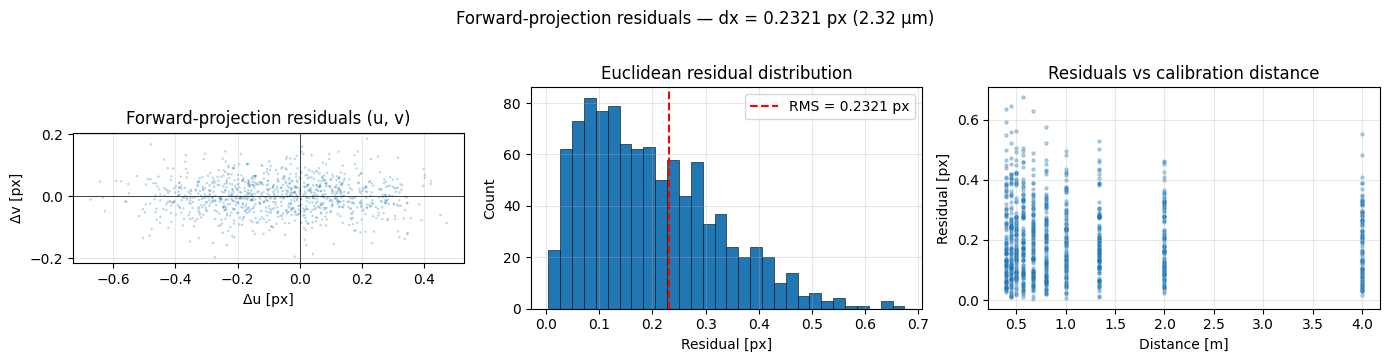

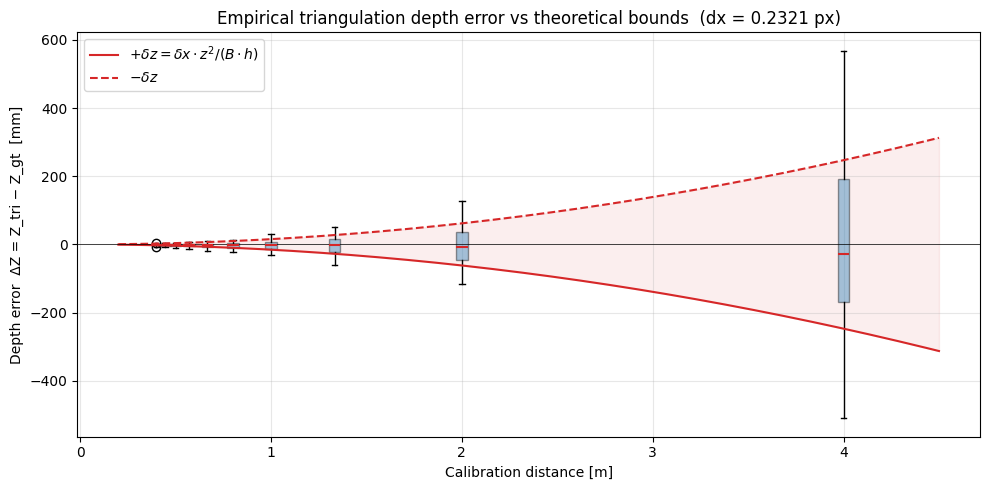

In [71]:
# ── Part A: Estimate dx via forward-projection residuals ─────────────────
# For each dot i at each calibration distance z_j, predict the pixel position
# from the calibrated model (V[i], AB, K) and compare with detected position.

pixel_pitch = 10e-6  # [m] — sensor pixel size
h_focal = fx * pixel_pitch  # physical focal length [m]

n_cal = len(cal_dists)
cal_z = np.array(cal_dists)  # calibration distances [m]
n_dots_cal = V.shape[0]

fwd_residuals_all = []       # (u_res, v_res) for every dot × distance
fwd_rms_per_dot = np.full(n_dots_cal, np.nan)
fwd_res_by_dist = [[] for _ in range(n_cal)]  # grouped by distance

for i in range(n_dots_cal):
    if not np.all(np.isfinite(V[i])):
        continue
    if abs(V[i, 2]) < 1e-12:
        continue

    dot_residuals = []
    for j in range(n_cal):
        if i >= len(subpixel_list[j]):
            continue
        sp = subpixel_list[j][i]
        u_det, v_det = sp["x"], sp["y"]
        if not (np.isfinite(u_det) and np.isfinite(v_det)):
            continue

        # Forward project: find where the calibrated ray hits z = cal_z[j]
        t = cal_z[j] / V[i, 2]
        P = B + t * V[i]
        u_pred = fx * P[0] / P[2] + cx
        v_pred = fy * P[1] / P[2] + cy

        du = u_det - u_pred
        dv = v_det - v_pred
        fwd_residuals_all.append((du, dv))
        dot_residuals.append(np.hypot(du, dv))
        fwd_res_by_dist[j].append(np.hypot(du, dv))

    if dot_residuals:
        fwd_rms_per_dot[i] = np.sqrt(np.mean(np.array(dot_residuals)**2))

fwd_residuals_all = np.array(fwd_residuals_all)  # (N, 2)
dx_pixels = np.sqrt(np.mean(fwd_residuals_all[:, 0]**2 + fwd_residuals_all[:, 1]**2))
dx_physical = dx_pixels * pixel_pitch  # [m]

print(f"Forward-projection localisation error (RMS):")
print(f"  dx = {dx_pixels:.4f} px  =  {dx_physical*1e6:.2f} µm")
print(f"  Physical focal length h = {h_focal*1e3:.3f} mm")
print(f"  Baseline AB = {AB*100:.3f} cm")
print(f"  Total residual samples: {len(fwd_residuals_all)}")

print(f"\nForward-projection residuals by distance:")
print(f"{'Dist [m]':>10s} {'RMS [px]':>10s} {'N':>5s}")
for j in range(n_cal):
    if fwd_res_by_dist[j]:
        rms_j = np.sqrt(np.mean(np.array(fwd_res_by_dist[j])**2))
        print(f"{cal_z[j]:10.1f} {rms_j:10.4f} {len(fwd_res_by_dist[j]):5d}")


# ── Part B: Empirical triangulation depth error at calibration distances ─
dz_by_dist = [[] for _ in range(n_cal)]  # signed depth errors per distance

for i in range(n_dots_cal):
    if not np.all(np.isfinite(V[i])):
        continue
    for j in range(n_cal):
        if i >= len(subpixel_list[j]):
            continue
        sp = subpixel_list[j][i]
        u_det, v_det = sp["x"], sp["y"]
        if not (np.isfinite(u_det) and np.isfinite(v_det)):
            continue

        Z_tri = dotCal.triangulate_depth(u_det, v_det, V[i], B, K_inv)
        dz = Z_tri - cal_z[j]
        dz_by_dist[j].append(dz)

dz_means = np.array([np.mean(errs) if errs else np.nan for errs in dz_by_dist])
dz_stds  = np.array([np.std(errs)  if errs else np.nan for errs in dz_by_dist])
dz_rmss  = np.array([np.sqrt(np.mean(np.array(errs)**2)) if errs else np.nan
                      for errs in dz_by_dist])

print(f"\nEmpirical triangulation depth error at calibration distances:")
print(f"{'Dist [m]':>10s} {'Mean [mm]':>10s} {'Std [mm]':>10s} {'RMS [mm]':>10s} {'N':>5s}")
for j in range(n_cal):
    n = len(dz_by_dist[j])
    print(f"{cal_z[j]:10.1f} {dz_means[j]*1e3:10.2f} {dz_stds[j]*1e3:10.2f} "
          f"{dz_rmss[j]*1e3:10.2f} {n:5d}")


# ── Theoretical error at reference distances ─────────────────────────────
ref_distances = np.array([0.5, 1.0, 2.0, 3.5])
dz_theory_ref = dx_physical * ref_distances**2 / (AB * h_focal)
print(f"\nTheoretical triangulation depth error  dz = dx·z²/(AB·h):")
for z_ref, dz_ref in zip(ref_distances, dz_theory_ref):
    print(f"  z = {z_ref:.1f} m  →  dz = {dz_ref*100:.2f} cm  ({dz_ref*1000:.1f} mm)")


# ── Plot 1: Forward-projection residual histograms ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Scatter of u,v residuals
axes[0].scatter(fwd_residuals_all[:, 0], fwd_residuals_all[:, 1],
                s=3, alpha=0.3, edgecolors="none")
axes[0].axhline(0, color="k", linewidth=0.5); axes[0].axvline(0, color="k", linewidth=0.5)
axes[0].set_aspect("equal")
axes[0].set_xlabel("Δu [px]"); axes[0].set_ylabel("Δv [px]")
axes[0].set_title("Forward-projection residuals (u, v)")
axes[0].grid(alpha=0.3)

# Histogram of Euclidean residuals
euc_res = np.hypot(fwd_residuals_all[:, 0], fwd_residuals_all[:, 1])
axes[1].hist(euc_res, bins=30, edgecolor="k", linewidth=0.4, color="C0")
axes[1].axvline(dx_pixels, color="red", linestyle="--",
                label=f"RMS = {dx_pixels:.4f} px")
axes[1].set_title("Euclidean residual distribution")
axes[1].set_xlabel("Residual [px]"); axes[1].set_ylabel("Count")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Residuals vs distance (scatter)
for j in range(n_cal):
    if fwd_res_by_dist[j]:
        axes[2].scatter([cal_z[j]] * len(fwd_res_by_dist[j]),
                        fwd_res_by_dist[j], s=5, alpha=0.3, color="C0")
axes[2].set_title("Residuals vs calibration distance")
axes[2].set_xlabel("Distance [m]"); axes[2].set_ylabel("Residual [px]")
axes[2].grid(alpha=0.3)

plt.suptitle(f"Forward-projection residuals — dx = {dx_pixels:.4f} px "
             f"({dx_physical*1e6:.2f} µm)", y=1.02)
plt.tight_layout(); plt.show()


# ── Plot 2: Empirical depth error box plot + theoretical curve ───────────
fig, ax = plt.subplots(figsize=(10, 5))

# Box plot of empirical depth errors at each calibration distance
bp_data = [np.array(errs) * 1e3 for errs in dz_by_dist]  # convert to mm
positions = cal_z
bp = ax.boxplot(bp_data, positions=positions, widths=0.06,
                patch_artist=True, manage_ticks=False,
                boxprops=dict(facecolor="C0", alpha=0.4),
                medianprops=dict(color="C3", linewidth=1.5))

# Theoretical curve: dz = dx · z² / (AB · h)
z_smooth = np.linspace(0.2, 4.5, 200)
dz_theory_curve = dx_physical * z_smooth**2 / (AB * h_focal) * 1e3  # [mm]
ax.plot(z_smooth,  dz_theory_curve, "C3", linewidth=1.5, label=r"$+\delta z = \delta x \cdot z^2 / (B \cdot h)$")
ax.plot(z_smooth, -dz_theory_curve, "C3", linewidth=1.5, linestyle="--",
        label=r"$-\delta z$")
ax.fill_between(z_smooth, -dz_theory_curve, dz_theory_curve, alpha=0.08, color="C3")

ax.axhline(0, color="k", linewidth=0.5)
ax.set_xlabel("Calibration distance [m]")
ax.set_ylabel("Depth error  ΔZ = Z_tri − Z_gt  [mm]")
ax.set_title(f"Empirical triangulation depth error vs theoretical bounds  "
             f"(dx = {dx_pixels:.4f} px)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

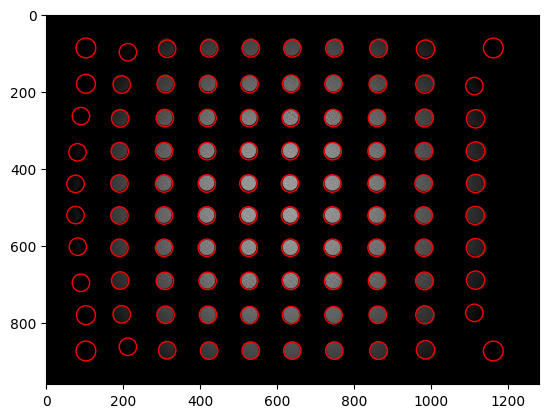

Detected dots in test SL: 100
Processed 100 dots


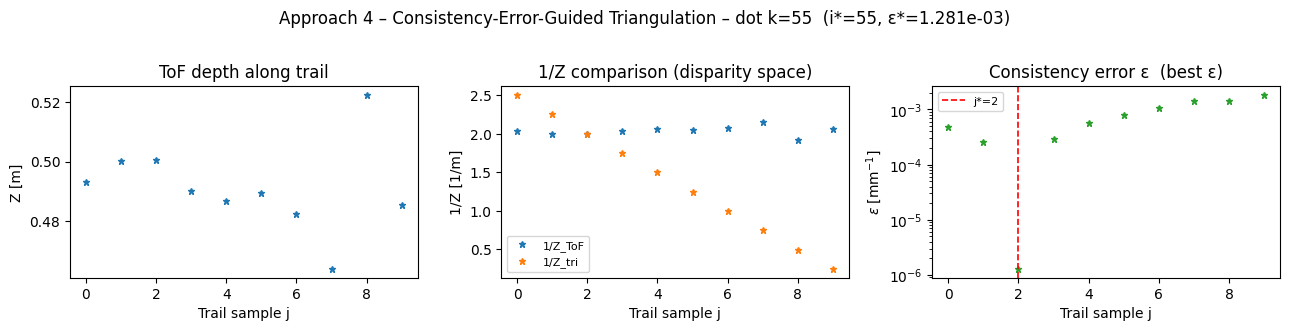

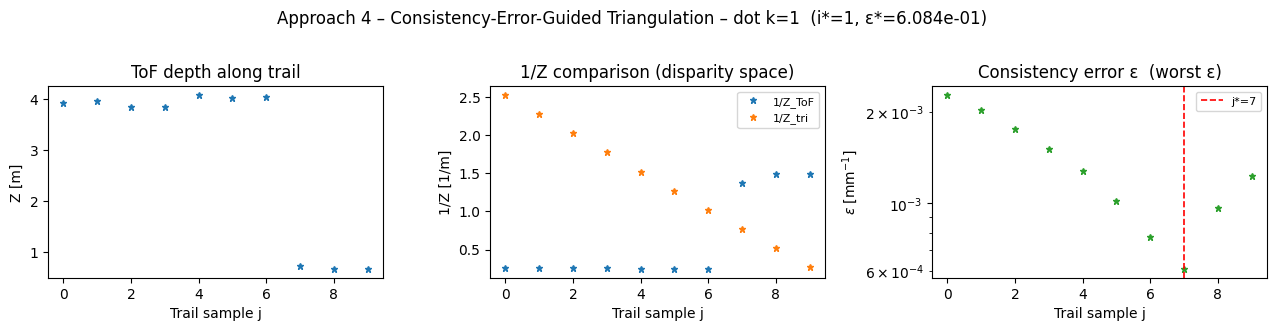

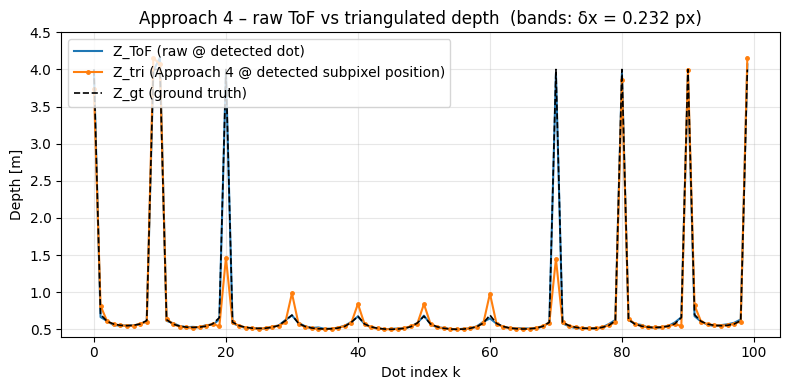

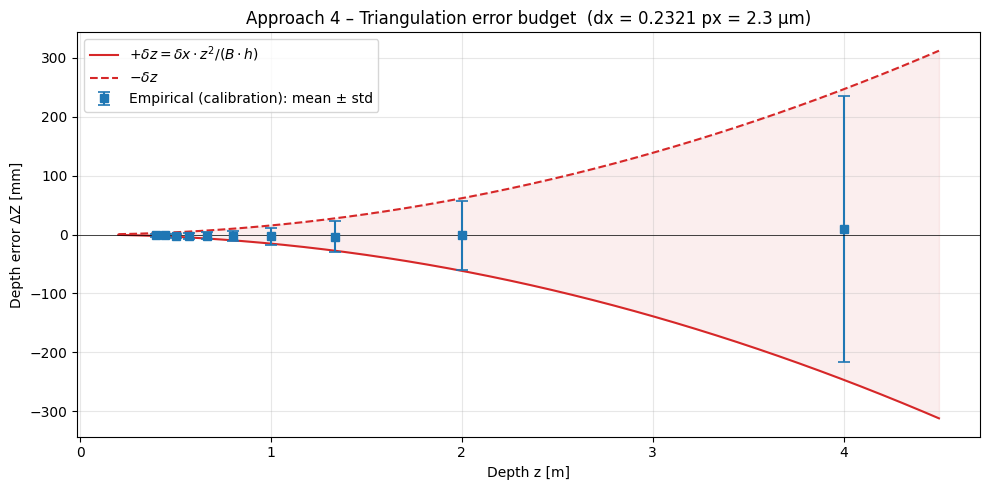

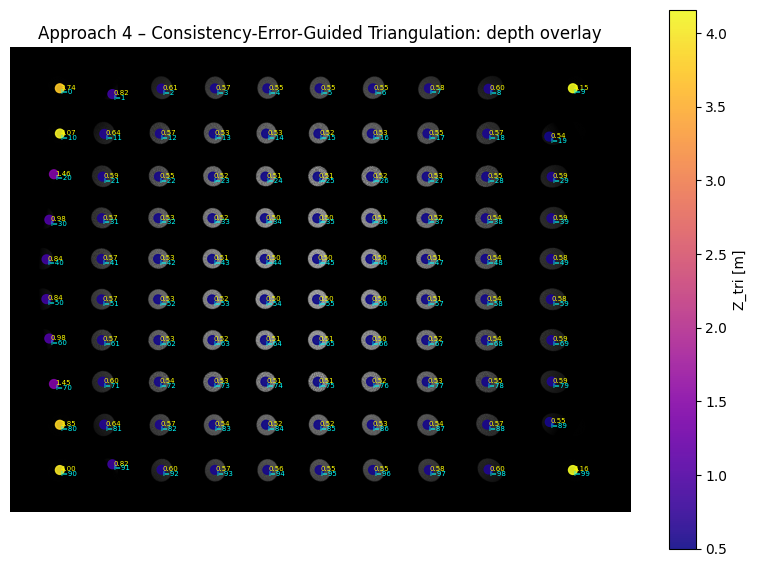

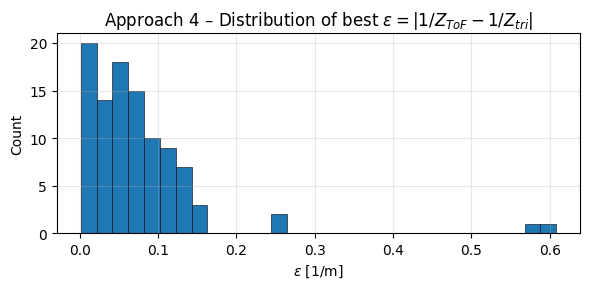

In [117]:
# ── Approach 4: Consistency-Error-Guided Triangulation ───────────────────
# Self-contained cell — reruns detection/matching (fast), outputs Z_tri instead of Z_tof.

# ── Inputs ─────────────────────────────────────────────────────────────
SL_TEST_4      = SL_TEST
TOF_TEST_4     = TOF_TEST
PCD_SCALE_4    = 0.001   # mm
EPS_THRESHOLD_4 = None   # set a float to invalidate high-ε dots

# ── Load test scene ──────────────────────────────────────────────────────
trail_xy_4 = dotCal.build_calibration_trails(subpixel_list)

tof_test_4   = dotCal.load_tof_pcd(TOF_TEST_4, unit_scale=PCD_SCALE_4, depth_mode="axial")
depth_map_4  = tof_test_4["depth_map"]
H4, W4       = depth_map_4.shape

if dots == 10:

    blobs_test_4, sl_gray_4 = dotCal.detect_blobs(
        SL_TEST_4, max_sigma=20, num_sigma=16, threshold=0.02, min_sigma=16, visualize=True
    )
elif dots == 20:
    blobs_test_4, sl_gray_4 = dotCal.detect_blobs(
        SL_TEST_4, max_sigma=5, num_sigma=3, threshold=0.001, min_sigma=3, visualize=True, add_synthetic_gaussian=False
    )

_, subpix_test_4 = dotCal.detect_subpixel_locations(
    blobs_test_4, sl_gray_4, mode="geometricCenter"
)
test_uv_4 = np.array([[d["x"], d["y"]] for d in subpix_test_4], dtype=float)
print(f"Detected dots in test SL: {len(subpix_test_4)}")


# ── ToF depth sampler ────────────────────────────────────────────────────
def sample_tof_depth_4(u, v, search_radius=3):
    """Sample axial ToF depth from organised depth_map with local fill."""
    for r in range(search_radius + 1):
        for dv in range(-r, r + 1):
            for du in range(-r, r + 1):
                u2, v2 = int(round(u)) + du, int(round(v)) + dv
                if 0 <= u2 < W4 and 0 <= v2 < H4:
                    z = depth_map_4[v2, u2]
                    if np.isfinite(z) and z > 1e-6:
                        return float(z), float(np.hypot(du, dv))
    return 1e-9, np.inf


# Trail KD-trees for fast dot-to-trail assignment
trail_trees_4 = [cKDTree(trail_xy_4[:, i, :]) for i in range(dots**2)]
n_dist_4 = trail_xy_4.shape[0]


# ── Run Approach 4 ──────────────────────────────────────────────────────
results_4 = []

for k, (uu, vv) in enumerate(test_uv_4):
    # a) assign dot to calibration ray (nearest trail)
    best_i, best_dist = min(
        enumerate(trail_trees_4),
        key=lambda t: t[1].query([uu, vv], k=1)[0]
    )
    best_dist = trail_trees_4[best_i].query([uu, vv], k=1)[0]

    # b) compute ε along all trail samples
    Z_tri_arr = np.empty(n_dist_4)
    Z_tof_arr = np.empty(n_dist_4)
    eps_arr   = np.empty(n_dist_4)

    for j in range(n_dist_4):
        uij = float(trail_xy_4[j, best_i, 0])
        vij = float(trail_xy_4[j, best_i, 1])
        Z_tri = dotCal.triangulate_depth(uij, vij, V[best_i], B, K_inv)
        Z_tof, _ = sample_tof_depth_4(uij, vij)
        Z_tri_arr[j] = max(Z_tri, 1e-9)
        Z_tof_arr[j] = max(Z_tof, 1e-9)
        eps_arr[j]   = dotCal.consistency_error(Z_tof_arr[j], Z_tri_arr[j])

    # c) select min-ε sample → triangulate from subpixel-detected dot position
    j_best   = int(np.argmin(eps_arr))
    Z_raw, _ = sample_tof_depth_4(uu, vv)
    Z_out    = float(dotCal.triangulate_depth(uu, vv, V[best_i], B, K_inv))  # continuous: uses actual detected position
    if EPS_THRESHOLD_4 is not None and float(eps_arr[j_best]) > EPS_THRESHOLD_4:
        Z_out = float("nan")

    results_4.append(dict(
        k=k, u=float(uu), v=float(vv),
        Z_raw=Z_raw, Z_out=Z_out,
        Z_gt=ground_truth_depth(uu, vv),
        i_best=best_i, j_best=j_best,
        eps_best=float(eps_arr[j_best]),
        eps_curve=eps_arr.copy(),
        Z_tri_curve=Z_tri_arr.copy(),
        Z_tof_curve=Z_tof_arr.copy(),
    ))

print(f"Processed {len(results_4)} dots")


# ── ε-curve plots (best and worst dot) ──────────────────────────────────
eps_all_4 = np.array([r["eps_best"] for r in results_4], float)
for label, k_ex in [("best ε", int(np.argmin(eps_all_4))),
                     ("worst ε", int(np.argmax(eps_all_4)))]:
    ex  = results_4[k_ex]
    x   = np.arange(n_dist_4)
    eps_plot = ex["eps_curve"] * 1e-3   # 1/m → 1/mm (paper scale)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    axes[0].plot(x, ex["Z_tof_curve"], "*", markersize=5)
    axes[0].set_title("ToF depth along trail")
    axes[0].set_xlabel("Trail sample j"); axes[0].set_ylabel("Z [m]")

    axes[1].plot(x, 1 / ex["Z_tof_curve"], "*", markersize=5, label="1/Z_ToF")
    axes[1].plot(x, 1 / ex["Z_tri_curve"], "*", markersize=5, label="1/Z_tri")
    axes[1].set_title("1/Z comparison (disparity space)")
    axes[1].set_xlabel("Trail sample j"); axes[1].set_ylabel("1/Z [1/m]")
    axes[1].legend(fontsize=8)

    axes[2].semilogy(x, eps_plot, "*", markersize=5, color="C2")
    axes[2].axvline(ex["j_best"], color="red", linewidth=1.2, linestyle="--",
                    label=f"j*={ex['j_best']}")
    axes[2].set_title(f"Consistency error ε  ({label})")
    axes[2].set_xlabel("Trail sample j")
    axes[2].set_ylabel(r"$\varepsilon$ [mm$^{-1}$]")
    axes[2].legend(fontsize=8)

    plt.suptitle(
        f"Approach 4 – Consistency-Error-Guided Triangulation – dot k={ex['k']}  "
        f"(i*={ex['i_best']}, ε*={ex['eps_best']:.3e})", y=1.02
    )
    plt.tight_layout(); plt.show()


# ── Depth per dot: raw ToF vs Approach 4 Z_tri + error bands ───────────
ref_distances_4 = np.array([0.5, 1.0, 2.0, 3.5])
dz_bounds_4 = dx_physical * ref_distances_4**2 / (AB * h_focal)
band_colors = ["C2", "C3", "C4", "C5"]

plt.figure(figsize=(8, 4))
plt.ylim(0.4,4.5) ############################
plt.plot([r["k"] for r in results_4], [r["Z_raw"] for r in results_4],
         "-", markersize=5, label="Z_ToF (raw @ detected dot)")
plt.plot([r["k"] for r in results_4], [r["Z_out"] for r in results_4],
         ".-", markersize=5, label="Z_tri (Approach 4 @ detected subpixel position)")
plt.plot([r["k"] for r in results_4], [r["Z_gt"] for r in results_4],
         "k--", linewidth=1.2, label="Z_gt (ground truth)")

"""for idx, (z_ref, dz_ref) in enumerate(zip(ref_distances_4, dz_bounds_4)):
    color = band_colors[idx]
    plt.axhspan(z_ref - dz_ref, z_ref + dz_ref, alpha=0.12, color=color)
    plt.axhline(z_ref, linestyle="--", color=color, alpha=0.5, linewidth=0.8)
    plt.text(len(results_4) + 0.5, z_ref, f"{z_ref:.1f} m ± {dz_ref*100:.1f} cm",
             fontsize=7, color=color, va="center")"""

plt.title(f"Approach 4 – raw ToF vs triangulated depth  "
          f"(bands: δx = {dx_pixels:.3f} px)")
plt.xlabel("Dot index k"); plt.ylabel("Depth [m]")
plt.legend(loc="upper left"); plt.grid(alpha=0.3)
#plt.xlim(-1, len(results_4) + 8) ################################
#plt.xlim(0,100)
plt.tight_layout(); plt.show()


# ── Error budget: theoretical envelope + empirical calibration errors ────
fig, ax = plt.subplots(figsize=(10, 5))

# Theoretical envelope: dz = dx · z² / (AB · h)
z_smooth = np.linspace(0.2, 4.5, 200)
dz_theory = dx_physical * z_smooth**2 / (AB * h_focal) * 1e3  # [mm]
ax.plot(z_smooth,  dz_theory, "C3", linewidth=1.5,
        label=r"$+\delta z = \delta x \cdot z^2 / (B \cdot h)$")
ax.plot(z_smooth, -dz_theory, "C3", linewidth=1.5, linestyle="--",
        label=r"$-\delta z$")
ax.fill_between(z_smooth, -dz_theory, dz_theory, alpha=0.08, color="C3")

# Empirical calibration errors as error bars (from Cell 17)
ax.errorbar(cal_z, dz_means * 1e3, yerr=dz_stds * 1e3,
            fmt="s", markersize=6, color="C0", capsize=4, capthick=1.2,
            label="Empirical (calibration): mean ± std")

ax.axhline(0, color="k", linewidth=0.5)
ax.set_xlabel("Depth z [m]")
ax.set_ylabel("Depth error ΔZ [mm]")
ax.set_title(f"Approach 4 – Triangulation error budget  "
             f"(dx = {dx_pixels:.4f} px = {dx_physical*1e6:.1f} µm)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# ── Depth overlay on SL image ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(sl_gray_4, cmap="gray")
xs = np.array([r["u"] for r in results_4])
ys = np.array([r["v"] for r in results_4])
zs = np.array([r["Z_out"] for r in results_4])
valid_4 = np.isfinite(zs)
sc = ax.scatter(xs[valid_4], ys[valid_4], s=40, c=zs[valid_4], cmap="plasma", alpha=0.9)
plt.colorbar(sc, ax=ax, label="Z_tri [m]")
for r in results_4:
    if np.isfinite(r["Z_out"]):
        ax.text(r["u"] + 2, r["v"] + 2,  f'{r["Z_out"]:.2f}', fontsize=5, color="yellow")
        ax.text(r["u"] + 2, r["v"] + 12, f'i={r["i_best"]}',  fontsize=5, color="cyan")
ax.set_title("Approach 4 – Consistency-Error-Guided Triangulation: depth overlay")
ax.axis("off"); plt.show()


# ── ε histogram ─────────────────────────────────────────────────────────
plt.figure(figsize=(6, 3))
plt.hist(eps_all_4, bins=30, edgecolor="k", linewidth=0.4)
if EPS_THRESHOLD_4 is not None:
    plt.axvline(EPS_THRESHOLD_4, color="red", label=f"threshold={EPS_THRESHOLD_4:.3e}")
    plt.legend()
plt.title(r"Approach 4 – Distribution of best $\varepsilon = |1/Z_{ToF} - 1/Z_{tri}|$")
plt.xlabel(r"$\varepsilon$ [1/m]"); plt.ylabel("Count")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()